In [3]:
# Import important packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Data Preprocessing and EDA
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold
import shap

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import random

# Bias and Fairness Analysis
!pip install fairlearn
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer
import scipy.stats as stats

Load Data

In [ ]:
data = pd.read_excel('Student dropout.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Drop duplicates from dataset.

In [5]:
data.drop_duplicates()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000e+00,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,1.366667e+16,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000e+00,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,1.240000e+01,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,1.300000e+01,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,1.266667e+16,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,1.100000e+01,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,1.350000e+01,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,1.200000e+01,0,9.4,-0.8,-3.12,Graduate


Rename columns to fix typos and replace spaces and parentheses with underscores. 
Convert categorical data astype category. 

In [6]:
# Fixing typos and standardize column name
data.rename(columns={'Nacionality':'Nationality', "Mother's qualification": "Mother_qualification", 
                     "Father's qualification":"Father_qualification", "Mother's occupation": "Mother_occupation", 
                     "Father's occupation": "Father_occupation", 'Age at enrollment':'Age', 'Daytime/evening attendance\t': 'Daytime/evening'}, inplace=True)
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("(", "")
data.columns = data.columns.str.replace(")", "")

# Convert data type
categorical_col = ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime/evening', 
                   'Previous_qualification', 'Nationality', 'Mother_qualification', 'Father_qualification', 
                   'Mother_occupation', 'Father_occupation', 'Displaced', 'Educational_special_needs', 'Debtor', 
                   'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International', 'Target']
data[categorical_col] = data[categorical_col].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   Marital_status                                4424 non-null   category
 1   Application_mode                              4424 non-null   category
 2   Application_order                             4424 non-null   category
 3   Course                                        4424 non-null   category
 4   Daytime/evening                               4424 non-null   category
 5   Previous_qualification                        4424 non-null   category
 6   Previous_qualification_grade                  4424 non-null   float64 
 7   Nationality                                   4424 non-null   category
 8   Mother_qualification                          4424 non-null   category
 9   Father_qualification                          4424 n

Simplify classification with mapping and drop the old column.

In [7]:
# Define the mapping dictionary based on the level of education
education_map = {
    # Higher Education
    2: 'Higher_Education',  # Higher education - bachelor's degree
    3: 'Higher_Education',  # Higher education - degree
    4: 'Higher_Education',  # Higher education - master's
    5: 'Higher_Education',  # Higher education - doctorate
    6: 'Higher_Education',  # Frequency of higher education (enrolled in higher education)
    40: 'Higher_Education', # Higher education - degree (1st cycle)
    41: 'Higher_Education', # Specialized higher studies course
    42: 'Higher_Education', # Professional higher technical course
    43: 'Higher_Education', # Higher education - Master (2nd cycle)
    44: 'Higher_Education', # Higher education - Doctorate (3rd cycle)
    
    # Secondary Education
    1: 'Secondary_Education',  # Secondary Education - 12th Year of Schooling or Eq.
    12: 'Secondary_Education', # Other - 11th Year of Schooling
    13: 'Secondary_Education', # 2nd year complementary high school course
    18: 'Secondary_Education', # General commerce course
    20: 'Secondary_Education', # Complementary High School Course 
    22: 'Secondary_Education', # Technical-professional course
    27: 'Secondary_Education', # 2nd cycle of the general high school course
    31: 'Secondary_Education', # General Course of Administration and Commerce
    33: 'Secondary_Education', # Supplementary Accounting and Administration
    39: 'Secondary_Education', # Technological specialization course
    
    # Basic Education
    9: 'Basic_Education',   # 12th year of schooling - not completed
    10: 'Basic_Education',  # 11th year of schooling - not completed
    11: 'Basic_Education',  # 7th Year (Old)
    14: 'Basic_Education',  # 10th Year of Schooling
    19: 'Basic_Education',  # Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.
    25: 'Basic_Education',  # Complementary High School Course - not concluded
    26: 'Basic_Education',  # 7th year of schooling
    29: 'Basic_Education',  # 9th Year of Schooling - Not Completed
    30: 'Basic_Education',  # 8th year of schooling
    36: 'Basic_Education',  # Can read without having a 4th year of schooling
    37: 'Basic_Education',  # Basic education 1st cycle (4th/5th year) or equiv.
    38: 'Basic_Education',  # Basic education 2nd cycle (6th/7th/8th year) or equiv.
    
    # No Formal Education
    35: 'No_Formal_Education', # Can't read or write
    
    # Unknown
    34: 'Unknown' # Unknown
}

# Map both columns at the same time
for col in ['Father_qualification', 'Mother_qualification']:
    # First convert back to integer if pandas treats them as category labels
    data[col] = data[col].astype(int)
    
    # Apply the mapping and convert to a clean categorical type
    data[f'{col}_grouped'] = data[col].map(education_map).astype('category')
data.drop(['Father_qualification', 'Mother_qualification'], axis = 1, inplace = True)

print(data['Father_qualification_grouped'].value_counts())
print(data['Mother_qualification_grouped'].value_counts())

Father_qualification_grouped
Basic_Education        2918
Secondary_Education     972
Higher_Education        420
Unknown                 112
No_Formal_Education       2
Name: count, dtype: int64
Mother_qualification_grouped
Basic_Education        2550
Secondary_Education    1122
Higher_Education        619
Unknown                 130
No_Formal_Education       3
Name: count, dtype: int64


In [8]:
# Define the mapping dictionary based on the level of education
education_map_prev = {
    # Higher Education
    2: 'Higher_Education',  # Higher education - bachelor's degree
    3: 'Higher_Education',  # Higher education - degree
    4: 'Higher_Education',  # Higher education - master's
    5: 'Higher_Education',  # Higher education - doctorate
    40: 'Higher_Education', # Higher education - degree (1st cycle)
    43: 'Higher_Education', # Higher education - master (2nd cycle)
    
    # Secondary Education
    1: 'Secondary_Education',  # Secondary education
    12: 'Secondary_Education', # Other - 11th year of schooling
    
    # Basic or Incomplete
    9: 'Basic_or_Incomplete',  # 12th year of schooling - not completed
    10: 'Basic_or_Incomplete', # 11th year of schooling - not completed
    14:'Basic_or_Incomplete',  # 10th year of schooling
    15: 'Basic_or_Incomplete', # 10th year of schooling - not completed
    19: 'Basic_or_Incomplete', # Basic education 3rd cycle (9th/10th/11th year) or equiv.
    38: 'Basic_or_Incomplete', # Basic education 2nd cycle (6th/7th/8th year) or equiv.
    
    # Technical or Short Cycle
    6: 'Technical_or_Short_Cycle',  # Frequency of higher education (enrolled in higher education)
    39: 'Technical_or_Short_Cycle', # Technological specialization course
    42: 'Technical_or_Short_Cycle', # Professional higher technical course
    
}

# Map the column
for col in ['Previous_qualification']:
    # First convert back to integer if pandas treats them as category labels
    data[col] = data[col].astype(int)
    
    # Apply the mapping and convert to a clean categorical type
    data[f'{col}_grouped'] = data[col].map(education_map_prev).astype('category')
data.drop(['Previous_qualification'], axis = 1, inplace = True)

print(data['Previous_qualification_grouped'].value_counts())

Previous_qualification_grouped
Secondary_Education         3762
Technical_or_Short_Cycle     271
Higher_Education             204
Basic_or_Incomplete          187
Name: count, dtype: int64


In [9]:
# Define the mapping dictionary based on the type of occupation
occupation_map = {
    # Managerial & Professional
    1: 'Managerial_Professional',   # Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers
    2: 'Managerial_Professional',   # Specialists in Intellectual and Scientific Activities
    112: 'Managerial_Professional', # Directors of administrative and commercial services
    114: 'Managerial_Professional', # Hotel, catering, trade and other services directors
    121: 'Managerial_Professional', # Specialists in the physical sciences, mathematics, engineering and related techniques
    122: 'Managerial_Professional', # Health professionals
    123: 'Managerial_Professional', # teachers
    124: 'Managerial_Professional', # Specialists in finance, accounting, administrative organization, public and commercial relations 
    125: 'Managerial_Professional', # Specialists in information and communication technologies (ICT)
    
    # Technical & Administrative
    3: 'Technical_Administrative',   # Intermediate Level Technicians and Professions
    4: 'Technical_Administrative',   # Administrative staff
    131: 'Technical_Administrative', # Intermediate level science and engineering technicians and professions
    132: 'Technical_Administrative', # Technicians and professionals, of intermediate level of health
    134: 'Technical_Administrative', # Intermediate level technicians from legal, social, sports, cultural and similar services
    135: 'Technical_Administrative', # Information and communication technology technicians
    141: 'Technical_Administrative', # Office workers, secretaries in general and data processing operators
    143: 'Technical_Administrative', # Data, accounting, statistical, financial services and registry-related operators 
    144: 'Technical_Administrative', # Other administrative support staff
    
    # Services & Sales
    5: 'Services_Sales',   # Personal Services, Security and Safety Workers and Sellers
    151: 'Services_Sales', # personal service worker
    152: 'Services_Sales', # sellers
    153: 'Services_Sales', # Personal care workers and the like
    154: 'Services_Sales', # Protection and security services personnel
    
    # Skilled Blue Collar (Agriculture, Crafts, Machine Operators)
    6: 'Skilled_Blue_Collar',   # Farmers and Skilled Workers in Agriculture, Fisheries and Forestry
    7: 'Skilled_Blue_Collar',   # Skilled Workers in Industry, Construction and Craftsmen
    8: 'Skilled_Blue_Collar',   # Installation and Machine Operators and Assembly Workers
    161: 'Skilled_Blue_Collar', # Market-oriented farmers and skilled agricultural and animal production workers
    163: 'Skilled_Blue_Collar', # Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence
    171: 'Skilled_Blue_Collar', # Skilled construction workers and the like, except electricians
    172: 'Skilled_Blue_Collar', # Skilled workers in metallurgy, metalworking and similar
    174: 'Skilled_Blue_Collar', # Skilled workers in electricity and electronics
    175: 'Skilled_Blue_Collar', # Workers in food processing, woodworking, clothing and other industries and crafts
    181: 'Skilled_Blue_Collar', # Fixed plant and machine operators
    182: 'Skilled_Blue_Collar', # assembly workers
    183: 'Skilled_Blue_Collar', # Vehicle drivers and mobile equipment operators

    # Unskilled Labor
    9: 'Unskilled_Labor',   # Unskilled Workers
    191: 'Unskilled_Labor', # cleaning
    192: 'Unskilled_Labor', # Unskilled workers in agriculture, animal production, fisheries and forestry
    193: 'Unskilled_Labor', # Unskilled workers in extractive industry, construction, manufacturing and transport
    194: 'Unskilled_Labor', # Meal preparation assistants
    195: 'Unskilled_Labor', # Street vendors (except food) and street service providers

    # Other / Unknown / Special Categories
    0: 'Other_Unknown',   # Student
    10: 'Other_Unknown',  # Armed Forces Professions 
    90: 'Other_Unknown',  # Other Situation
    99: 'Other_Unknown',  # (blank)
    101: 'Other_Unknown', # Armed Forces Officers
    102: 'Other_Unknown', # Armed Forces Sergeants
    103: 'Other_Unknown'  # Armed Forces Sergeants
}

# Map both columns at the same time
for col in ['Mother_occupation', 'Father_occupation']:
    # First convert back to integer if pandas treats them as category labels
    data[col] = data[col].astype(int)
    
    # Apply the mapping and convert to a clean categorical type
    data[f'{col}_grouped'] = data[col].map(occupation_map).fillna('Other_Unknown').astype('category')
data.drop(['Father_occupation', 'Mother_occupation'], axis = 1, inplace = True)
print(data['Father_occupation_grouped'].value_counts())
print(data['Mother_occupation_grouped'].value_counts())

Father_occupation_grouped
Skilled_Blue_Collar         1255
Unskilled_Labor             1034
Technical_Administrative     786
Services_Sales               523
Other_Unknown                485
Managerial_Professional      341
Name: count, dtype: int64
Mother_occupation_grouped
Unskilled_Labor             1623
Technical_Administrative    1193
Services_Sales               537
Managerial_Professional      430
Skilled_Blue_Collar          405
Other_Unknown                236
Name: count, dtype: int64


In [10]:
# Define the mapping dictionary based on the application mode
application_map = {
    # 1. Standard General Application Phases
    1: 'General_Contingent',   # 1st phase - general contingent
    17: 'General_Contingent',  # 2nd phase - general contingent
    18: 'General_Contingent',  # 3rd phase - general contingent
    
    # 2. Special Quotas, Contingents & Specific Ordinances
    2: 'Special_Quotas_Ordinance',  # Ordinance No. 612/93
    5: 'Special_Quotas_Ordinance',  # 1st phase - special contingent (Azores Island) 
    10: 'Special_Quotas_Ordinance', # Ordinance No. 854-B/99 
    15: 'Special_Quotas_Ordinance', # International student (bachelor)
    16: 'Special_Quotas_Ordinance', # 1st phase - special contingent (Madeira Island)
    26: 'Special_Quotas_Ordinance', # Ordinance No. 533-A/99, item b2) (Different Plan)
    27: 'Special_Quotas_Ordinance', # Ordinance No. 533-A/99, item b3) (Other Institution)
    
    # 3. Mature Age Route
    39: 'Mature_Over23',       # Over 23 years old
    
    # 4. Transfers, Re-entries, and Course Changes
    7: 'Transfer_Course_Change',   # Holders of other higher courses
    42: 'Transfer_Course_Change',  # Transfer
    43: 'Transfer_Course_Change',  # Change of course
    51: 'Transfer_Course_Change',  # Change of institution/course
    57: 'Transfer_Course_Change',  # Change of institution/course (International)
    
    # 5. Technical & Short-Cycle Diploma Tracks
    44: 'Technical_Short_Cycle',   # Technological specialization diploma holders
    53: 'Technical_Short_Cycle'    # Short cycle diploma holders
}

# Ensure column is clean, map it, and store as categorical
data['Application_mode'] = data['Application_mode'].astype(int)
data['Application_mode_grouped'] = data['Application_mode'].map(application_map).fillna('Special_Quotas').astype('category')
data.drop('Application_mode', axis = 1, inplace = True)

print(data['Application_mode_grouped'].value_counts())

Application_mode_grouped
General_Contingent          2704
Mature_Over23                785
Transfer_Course_Change       588
Technical_Short_Cycle        248
Special_Quotas_Ordinance      99
Name: count, dtype: int64


In [11]:
# List out corrupted columns
grade_cols = [
    'Curricular_units_1st_sem_grade', 
    'Curricular_units_2nd_sem_grade'
]

for col in grade_cols:
    # 1. Create a mask for values that are corrupted (greater than the max grade of 20)
    corrupted_mask = data[col] > 20
    
    if corrupted_mask.any():
        # Extract just the corrupted values
        corrupted_vals = data.loc[corrupted_mask, col]
        
        # 2. Dynamically find the power of 10 needed for each specific number
        # ceil(log10(val / 20)) gives exactly how many times we need to divide by 10
        powers = np.ceil(np.log10(corrupted_vals / 20.0))
        
        # 3. Apply the custom divisor (10^power) to each corrupted row
        data.loc[corrupted_mask, col] = corrupted_vals / (10 ** powers)
        
    # 4. Final safety clip to handle any weird floating-point rounding edges
    data[col] = np.clip(data[col], 0, 20)

# Verify the fix
print(data[grade_cols].describe().loc[['min', 'max']])

     Curricular_units_1st_sem_grade  Curricular_units_2nd_sem_grade
min                           0.000                        0.000000
max                          18.875                       18.571429


In [12]:
data.head()

,Marital_status,Application_order,Course,Daytime/evening,Previous_qualification_grade,Nationality,Admission_grade,Displaced,Educational_special_needs,Debtor,...,Unemployment_rate,Inflation_rate,GDP,Target,Father_qualification_grouped,Mother_qualification_grouped,Previous_qualification_grouped,Mother_occupation_grouped,Father_occupation_grouped,Application_mode_grouped
0,1,5,171,1,122.0,1,127.3,1,0,0,...,10.8,1.4,1.74,Dropout,Secondary_Education,Basic_Education,Secondary_Education,Services_Sales,Unskilled_Labor,General_Contingent
1,1,1,9254,1,160.0,1,142.5,1,0,0,...,13.9,-0.3,0.79,Graduate,Higher_Education,Secondary_Education,Secondary_Education,Technical_Administrative,Technical_Administrative,Special_Quotas_Ordinance
2,1,5,9070,1,122.0,1,124.8,1,0,0,...,10.8,1.4,1.74,Dropout,Basic_Education,Basic_Education,Secondary_Education,Unskilled_Labor,Unskilled_Labor,General_Contingent
3,1,2,9773,1,122.0,1,119.6,1,0,0,...,9.4,-0.8,-3.12,Graduate,Basic_Education,Basic_Education,Secondary_Education,Services_Sales,Technical_Administrative,General_Contingent
4,2,1,8014,0,100.0,1,141.5,0,0,0,...,13.9,-0.3,0.79,Graduate,Basic_Education,Basic_Education,Secondary_Education,Unskilled_Labor,Unskilled_Labor,Mature_Over23


In [13]:
# Check absolute counts and relative percentages for the Target
target_counts = data['Target'].value_counts()
target_pct = data['Target'].value_counts(normalize=True) * 100

target_balance = pd.DataFrame({
    'Counts': target_counts,
    'Percentage (%)': target_pct.round(2)
})
print("=== TARGET CLASS BALANCE ===")
print(target_balance)

=== TARGET CLASS BALANCE ===
          Counts  Percentage (%)
Target                          
Graduate    2209           49.93
Dropout     1421           32.12
Enrolled     794           17.95


Check for data balance by percentage distribution for categorical and skewness for numerical. High dominance and high skewness indicate data imbalance.

In [14]:
# Identify which columns are categorical vs numerical
cat_cols = data.select_dtypes(include=['category', 'object']).columns.tolist()
# Exclude 'Target' from the feature lists if it is included there
if 'Target' in cat_cols: cat_cols.remove('Target')

num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Target' in num_cols: num_cols.remove('Target')

# Check balance for all Categorical Features
print("=== CATEGORICAL FEATURE BALANCE (LOOK FOR HIGH DOMINANCE) ===")
cat_summary = []
for col in cat_cols:
    # Get percentage distribution of the most common category
    top_class_pct = data[col].value_counts(normalize=True).iloc[0] * 100
    top_class_name = data[col].value_counts().index[0]
    num_classes = data[col].nunique()
    
    cat_summary.append({
        'Feature': col,
        'Unique Categories': num_classes,
        'Most Common Category': top_class_name,
        'Dominance (%)': round(top_class_pct, 2)
    })

cat_data = pd.DataFrame(cat_summary).sort_values(by='Dominance (%)', ascending=False)
print(cat_data.to_string(index=False))


print("\n" + "="*60 + "\n")


# Check balance for all 19 Numerical Features
print("=== NUMERICAL FEATURE BALANCE (LOOK FOR HIGH SKEWNESS) ===")
num_summary = []
for col in num_cols:
    skewval = data[col].skew()
    # Check if data is highly concentrated on a single value (like 0 credits)
    top_val_pct = data[col].value_counts(normalize=True).iloc[0] * 100
    
    num_summary.append({
        'Feature': col,
        'Skewness': round(skewval, 2),
        'Top Value Dominance (%)': round(top_val_pct, 2)
    })

num_data = pd.DataFrame(num_summary).sort_values(by='Skewness', key=abs, ascending=False)
print(num_data.to_string(index=False))

=== CATEGORICAL FEATURE BALANCE (LOOK FOR HIGH DOMINANCE) ===
                       Feature  Unique Categories Most Common Category  Dominance (%)
     Educational_special_needs                  2                    0          98.85
                   Nationality                 21                    1          97.51
                 International                  2                    0          97.51
               Daytime/evening                  2                    1          89.08
                        Debtor                  2                    0          88.63
                Marital_status                  6                    1          88.58
       Tuition_fees_up_to_date                  2                    1          88.07
Previous_qualification_grouped                  4  Secondary_Education          85.04
            Scholarship_holder                  2                    0          75.16
             Application_order                  8                    1        

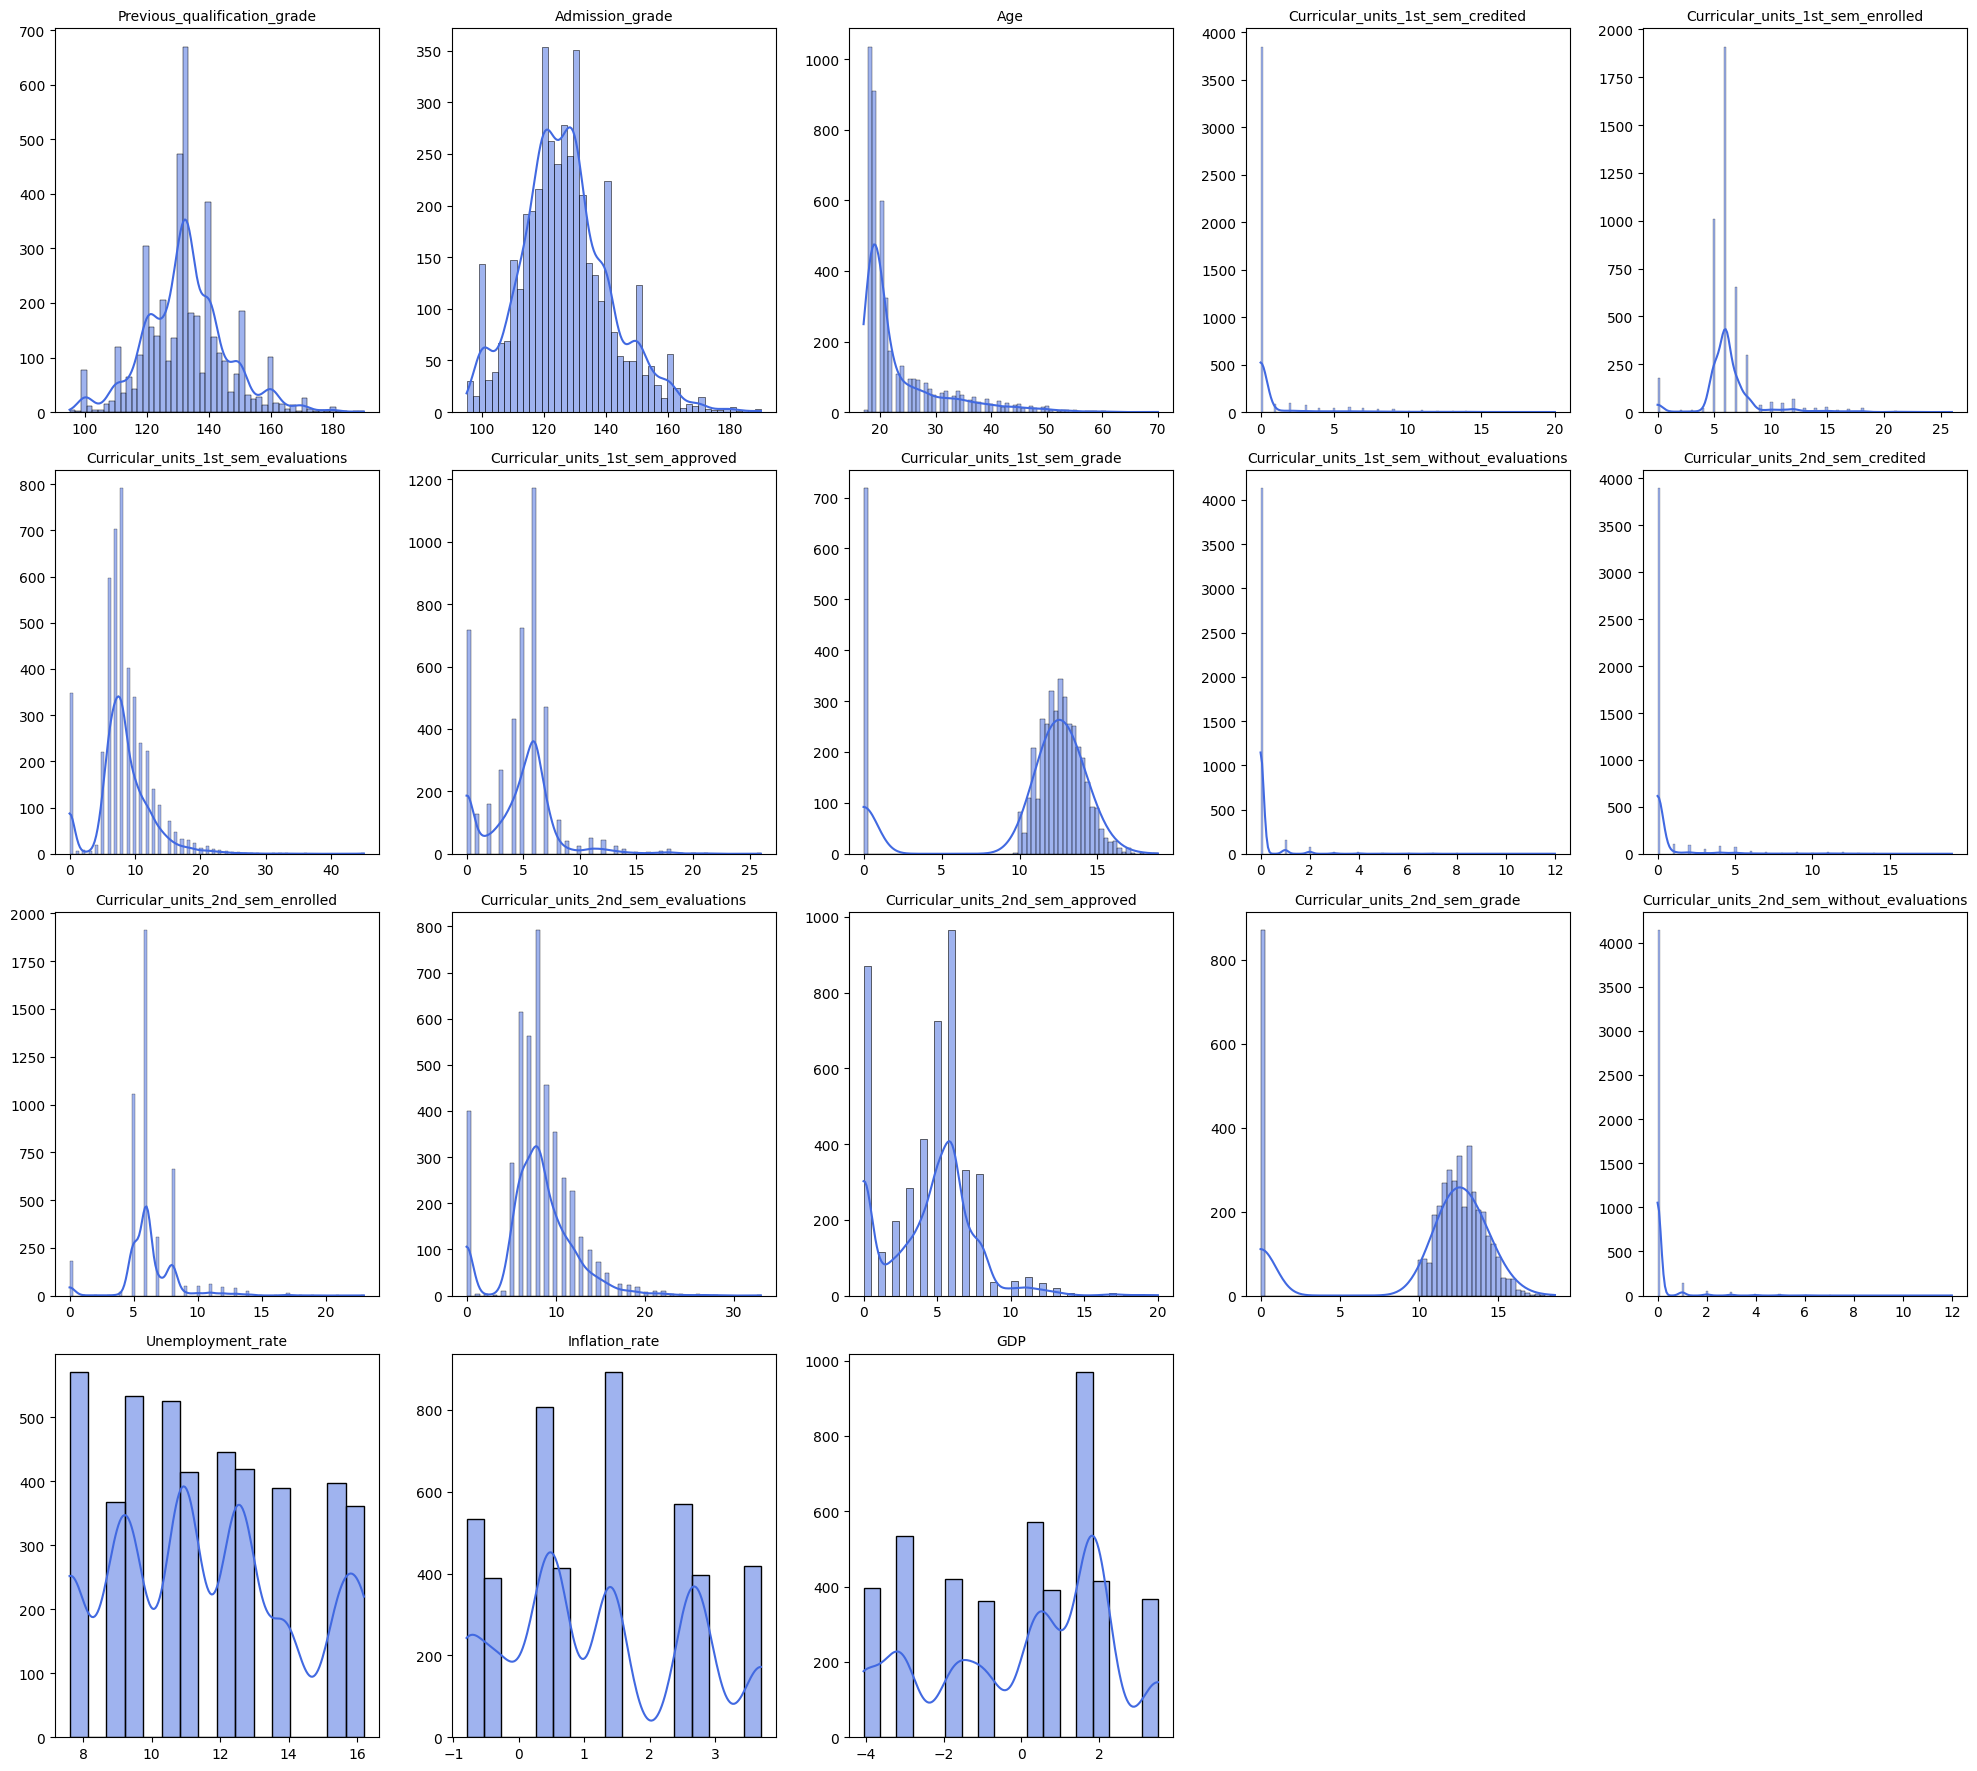

In [15]:
fig, axes = plt.subplots(5, 5, figsize=(20, 22))
axes = axes.flatten()  # Flatten into a 1D array to loop easily

for i, col in enumerate(num_cols):
    # Plot histogram with a density curve line
    sns.histplot(data[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Turn off any extra empty subplots 
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

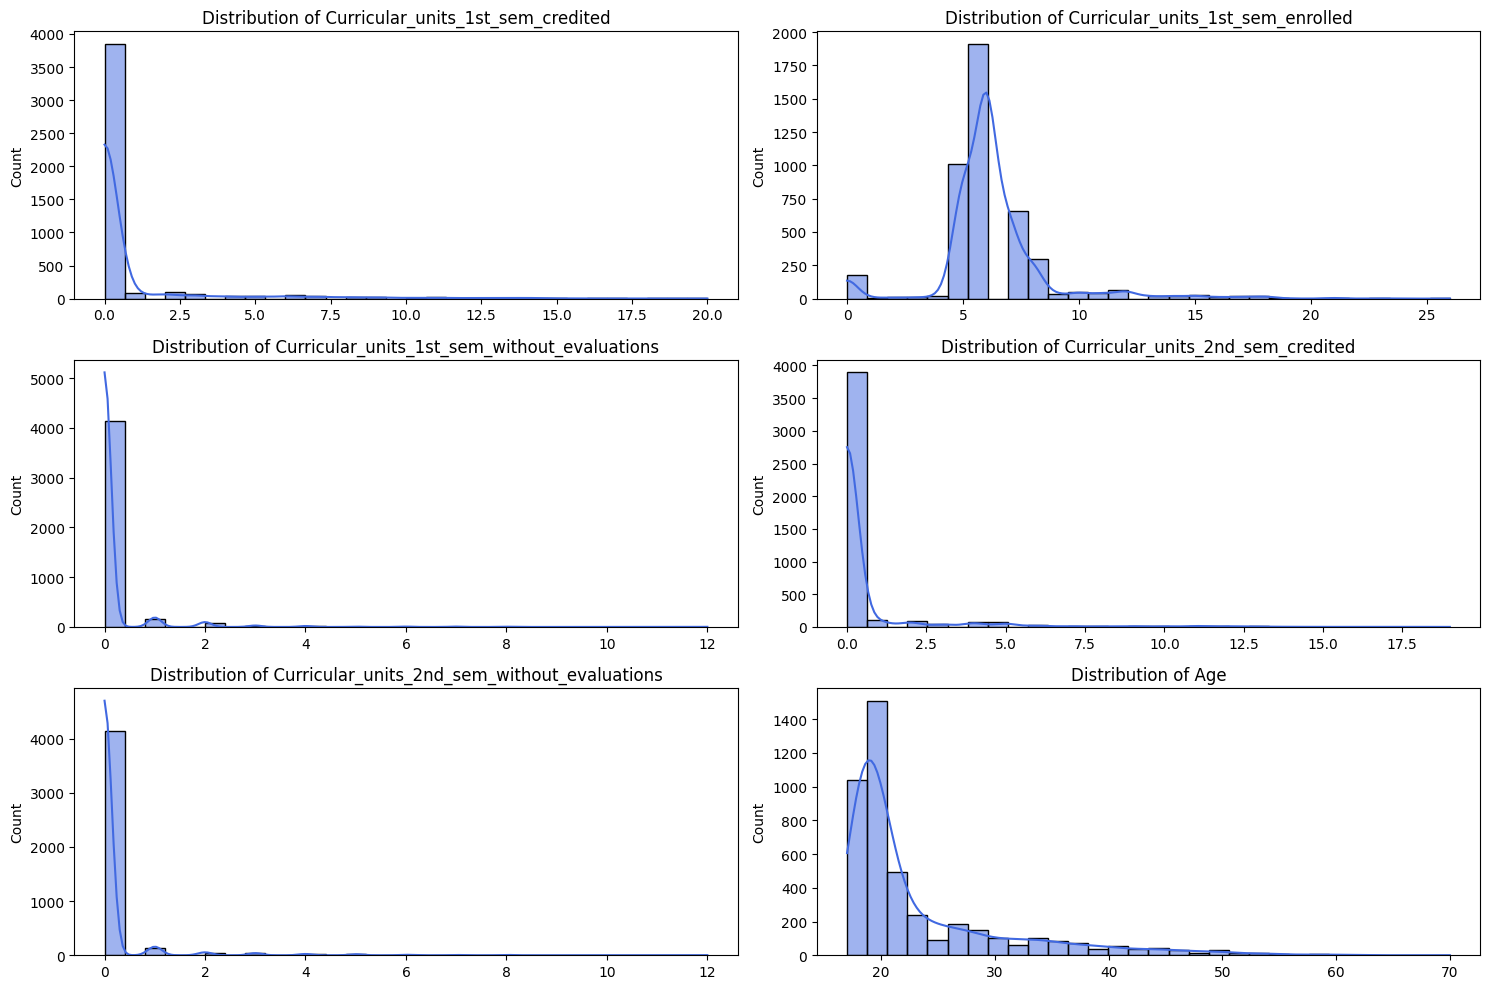

In [16]:
# Plotting the 6 most skewed columns
skewed_num_cols = [
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited',
    'Curricular_units_2nd_sem_without_evaluations',
    'Age',
    
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(skewed_num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

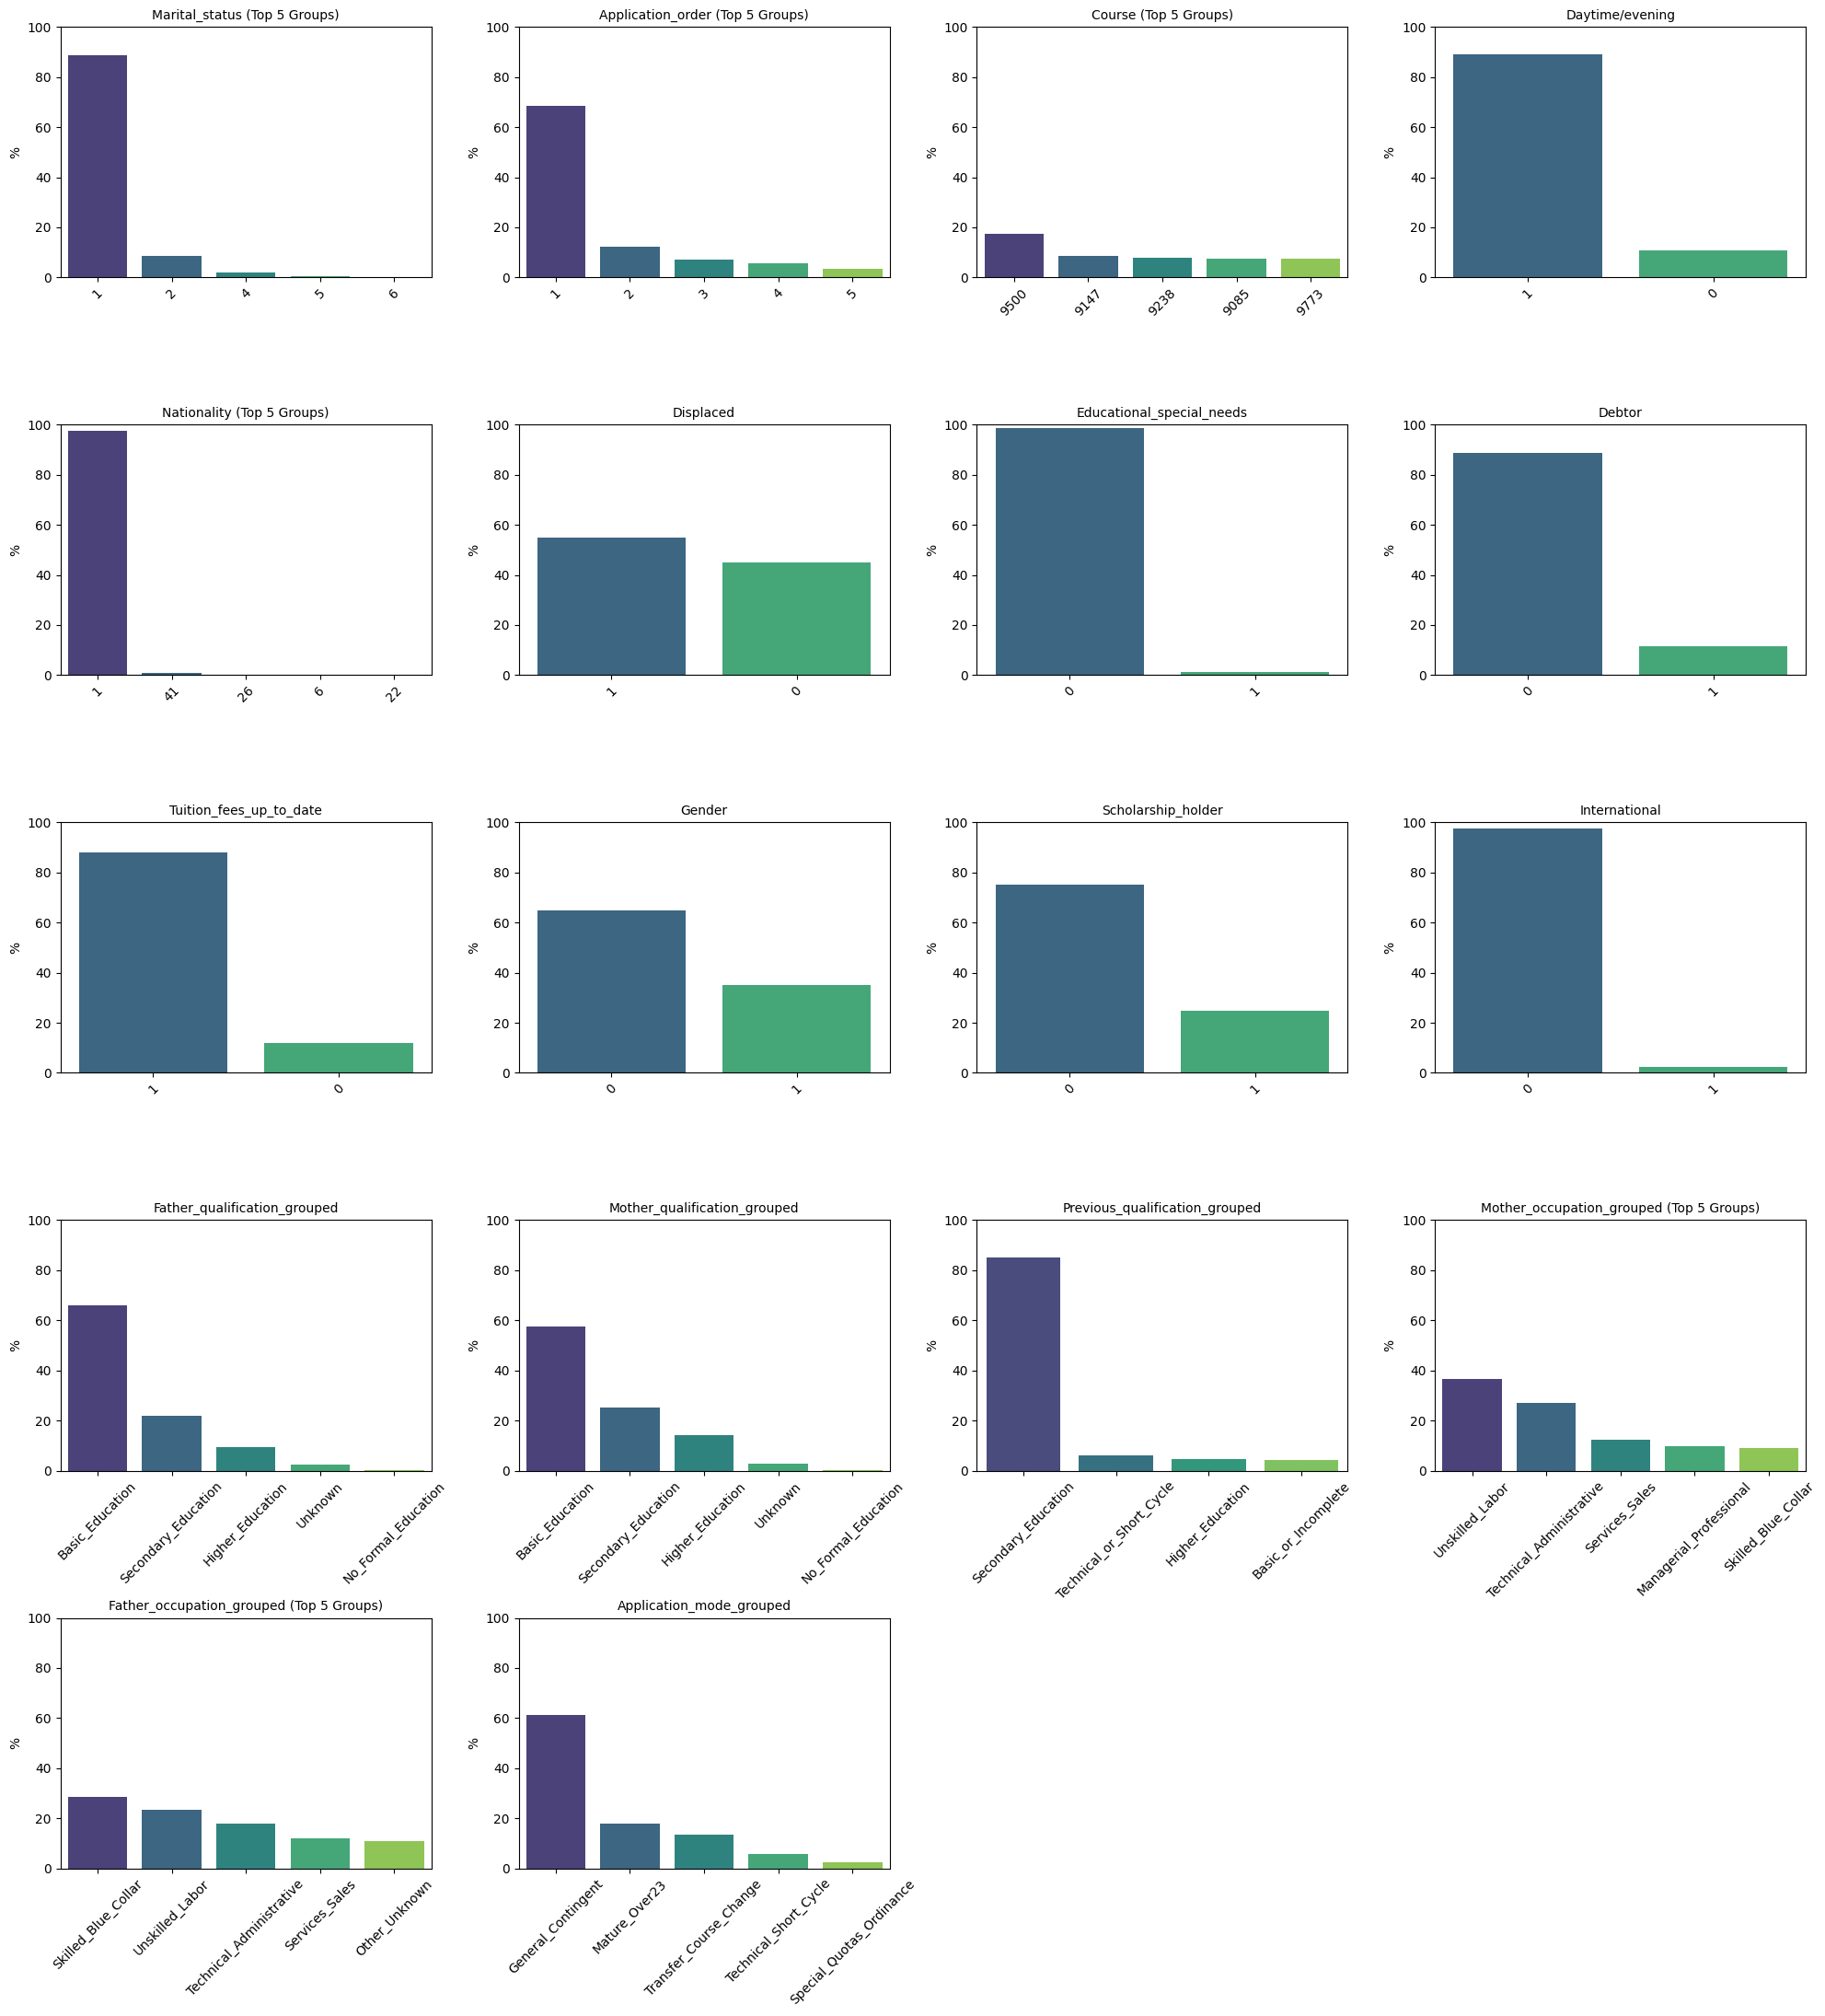

In [17]:
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate percentages for each unique category label
    data_pct = data[col].value_counts(normalize=True).mul(100).reset_index()
    data_pct.columns = [col, 'percentage']
    data_pct[col]=data_pct[col].astype(str)
    # Take only the top 5 most common categories if a column has way too many (like occupation) to make the chart readable
    if data[col].nunique() > 5:
        data_pct = data_pct.head(5)
        axes[i].set_title(f'{col} (Top 5 Groups)', fontsize=10)
    else:
        axes[i].set_title(f'{col}', fontsize=10)
        
    sns.barplot(x=col, y='percentage', data=data_pct, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('%')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)
    
# Clean up empty subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
# Check for missing values
data.isna().sum()

Marital_status                                  0
Application_order                               0
Course                                          0
Daytime/evening                                 0
Previous_qualification_grade                    0
Nationality                                     0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age                                             0
International                                   0
Curricular_units_1st_sem_credited               0
Curricular_units_1st_sem_enrolled               0
Curricular_units_1st_sem_evaluations            0
Curricular_units_1st_sem_approved               0
Curricular_units_1st_sem_grade                  0


In [19]:
# Evaluate categorical features to be dropped
def evaluate_imbalanced_feature(data, feature_col, target_col='Target', threshold=0.95):
    # Calculate baseline dropout rate
    baseline_dropout_rate = (data[target_col] == 'Dropout').mean()
    
    # Calculate dominance
    value_counts = data[feature_col].value_counts(normalize=True)
    most_common_pct = value_counts.iloc[0]
    most_common_val = value_counts.index[0]
    
    print(f"=== Evaluating: {feature_col} ===")
    print(f"• Dominance: {most_common_pct*100:.2f}% ({most_common_val})")
    
    if most_common_pct < threshold:
        print("DECISION: KEEP (Well below the safety variance limit).\n")
        return 'KEEP'
        
    # Isolate minority slice
    minority_data = data[data[feature_col] != most_common_val]
    minority_count = len(minority_data)
    
    if minority_count == 0:
        print("DECISION: DROP (Constant column, zero variance).\n")
        return 'DROP'
        
    minority_dropout_rate = (minority_data[target_col] == 'Dropout').mean()
    
    print(f"• Minority sample size: n = {minority_count}")
    print(f"• Baseline Dropout Rate: {baseline_dropout_rate*100:.1f}%")
    print(f"• Minority Dropout Rate: {minority_dropout_rate*100:.1f}%")
    
    # Check if minority group behaves drastically differently
    rate_diff = abs(minority_dropout_rate - baseline_dropout_rate)
    
    if minority_count >= 30 and rate_diff > 0.15:
        print("DECISION: KEEP (Tiny group, but possesses a strong, unique risk signal).\n")
        return 'KEEP'
    else:
        print("DECISION: DROP (Low variance and lacks a distinct target signal).\n")
        return 'DROP'


for col in cat_cols:
    evaluate_imbalanced_feature(data, col)

=== Evaluating: Marital_status ===
• Dominance: 88.58% (1)
DECISION: KEEP (Well below the safety variance limit).

=== Evaluating: Application_order ===
• Dominance: 68.40% (1)
DECISION: KEEP (Well below the safety variance limit).

=== Evaluating: Course ===
• Dominance: 17.31% (9500)
DECISION: KEEP (Well below the safety variance limit).

=== Evaluating: Daytime/evening ===
• Dominance: 89.08% (1)
DECISION: KEEP (Well below the safety variance limit).

=== Evaluating: Nationality ===
• Dominance: 97.51% (1)
• Minority sample size: n = 110
• Baseline Dropout Rate: 32.1%
• Minority Dropout Rate: 29.1%
DECISION: DROP (Low variance and lacks a distinct target signal).

=== Evaluating: Displaced ===
• Dominance: 54.84% (1)
DECISION: KEEP (Well below the safety variance limit).

=== Evaluating: Educational_special_needs ===
• Dominance: 98.85% (0)
• Minority sample size: n = 51
• Baseline Dropout Rate: 32.1%
• Minority Dropout Rate: 33.3%
DECISION: DROP (Low variance and lacks a distinct t

In [20]:
# Evaluate numerical features to be dropped
def evaluate_skewed_numerical_feature(data, feature_col, target_col='Target', skew_threshold=4.0):
    # Calculate baseline dropout rate
    dropout_mask = data[target_col] == 1 if data[target_col].dtype in [np.int64, np.float64] else data[target_col] == 'Dropout'
    baseline_dropout_rate = dropout_mask.mean()
    
    # Calculate Skewness
    feature_skew = data[feature_col].skew()
    
    print(f"=== Evaluating Numerical: {feature_col} ===")
    # Tier 1: If skewness is low/moderate, it's a well-distributed continuous feature
    if abs(feature_skew) < skew_threshold:
        print("DECISION: KEEP (Well-distributed continuous feature, below skew threshold).\n")
        return 'KEEP'
        
    # Tier 2: Extreme Skewness Audit (Zero-Inflated Spike Check)
    # Identify the dominant baseline value
    if data[feature_col].dtype == np.float64:
        most_common_val = 0.0
        dominance_pct = (data[feature_col] == 0.0).mean()
    else:
        # For integers, fall back to the standard mode matching
        most_common_val = data[feature_col].mode()[0]
        dominance_pct = (data[feature_col] == most_common_val).mean()
        
    print(f"• Baseline Target Value: {most_common_val} (Covers {dominance_pct*100:.2f}% of data)")
    
    print(f"• Dominant Local Value: {most_common_val} (Covers {dominance_pct*100:.2f}% of data)")
    
    # Isolate the minority slice
    minority_data = data[data[feature_col] != most_common_val]
    minority_count = len(minority_data)
        
    # Calculate dropout rate within the minority slice
    minority_dropout_mask = minority_data[target_col] == 1 if minority_data[target_col].dtype in [np.int64, np.float64] else minority_data[target_col] == 'Dropout'
    minority_dropout_rate = minority_dropout_mask.mean()
    
    print(f"• Anomaly Tail Sample Size: n = {minority_count}")
    print(f"• Baseline Dropout Rate: {baseline_dropout_rate*100:.1f}%")
    print(f"• Anomaly Tail Dropout Rate: {minority_dropout_rate*100:.1f}%")
    
    # Check if the skewed anomaly group behaves drastically differently from the baseline population
    rate_diff = abs(minority_dropout_rate - baseline_dropout_rate)
    
    # If the group has a reasonable sample size and shows a strong variance in outcome, keep the feature
    if minority_count >= 30 and rate_diff > 0.15:
        print("DECISION: KEEP (Highly skewed tail, but possesses a strong, unique risk signal).\n")
        return 'KEEP'
    else:
        print("DECISION: DROP (Extreme skewness acts as near-constant noise without distinct signal).\n")
        return 'DROP'

In [21]:
# Isolate the raw numerical columns dynamically
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

numerical_drops = []

# Loop through each column one by one
for col in num_cols:
    decision = evaluate_skewed_numerical_feature(data, col, target_col='Target')
    if decision == 'DROP':
        numerical_drops.append(col)

# Replace 2nd semester for trajectory delta
trajectory_replacements = ['Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_evaluations']
for col in trajectory_replacements:
    if col in data.columns and col not in numerical_drops:
        print(f"=== Structural Override: {col} ===")
        print("DECISION: DROP (Superceded by upcoming engineered trajectory delta).\n")
        numerical_drops.append(col)

# Drop redundant enrolled columns
enrollment_noise = ['Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled']
for col in enrollment_noise:
    if col in data.columns and col not in numerical_drops:
        print(f"=== Structural Override: {col} ===")
        print("DECISION: DROP (Redundant administrative enrollment volume tracking).\n")
        numerical_drops.append(col)


numerical_drops = sorted(list(set(numerical_drops)))

print("==================================================================")
print(f"NUMERICAL DROP LIST:\n{numerical_drops}")
print("==================================================================")

=== Evaluating Numerical: Previous_qualification_grade ===
DECISION: KEEP (Well-distributed continuous feature, below skew threshold).

=== Evaluating Numerical: Admission_grade ===
DECISION: KEEP (Well-distributed continuous feature, below skew threshold).

=== Evaluating Numerical: Age ===
DECISION: KEEP (Well-distributed continuous feature, below skew threshold).

=== Evaluating Numerical: Curricular_units_1st_sem_credited ===
• Baseline Target Value: 0 (Covers 86.96% of data)
• Dominant Local Value: 0 (Covers 86.96% of data)
• Anomaly Tail Sample Size: n = 577
• Baseline Dropout Rate: 32.1%
• Anomaly Tail Dropout Rate: 31.0%
DECISION: DROP (Extreme skewness acts as near-constant noise without distinct signal).

=== Evaluating Numerical: Curricular_units_1st_sem_enrolled ===
DECISION: KEEP (Well-distributed continuous feature, below skew threshold).

=== Evaluating Numerical: Curricular_units_1st_sem_evaluations ===
DECISION: KEEP (Well-distributed continuous feature, below skew thr

In [22]:
# Create delta features
data['Grade_Trajectory'] = data['Curricular_units_2nd_sem_grade'] - data['Curricular_units_1st_sem_grade']
data['Evaluations_Delta'] = data['Curricular_units_1st_sem_evaluations'] - data['Curricular_units_2nd_sem_evaluations']

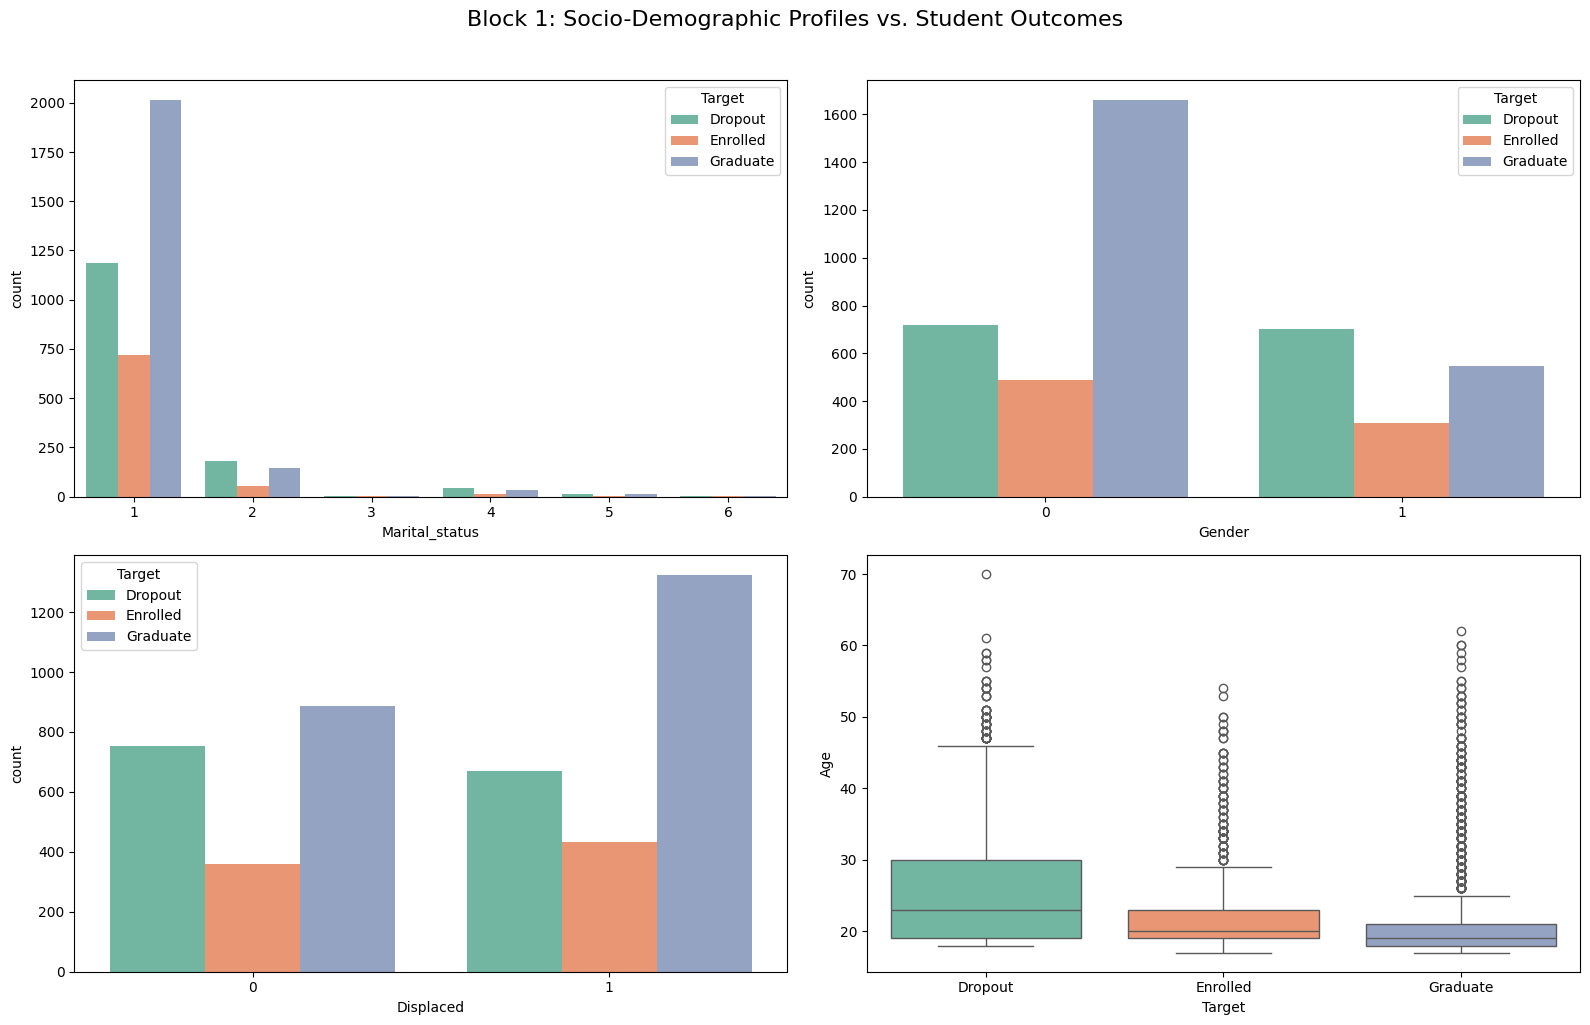

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Categorical checks
sns.countplot(x='Marital_status', hue='Target', data=data, ax=axes[0], palette='Set2')
sns.countplot(x='Gender', hue='Target', data=data, ax=axes[1], palette='Set2')
sns.countplot(x='Displaced', hue='Target', data=data, ax=axes[2], palette='Set2')

# Continuous check
sns.boxplot(x='Target', y='Age', hue='Target', data=data, ax=axes[3], palette='Set2')

plt.suptitle("Block 1: Socio-Demographic Profiles vs. Student Outcomes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

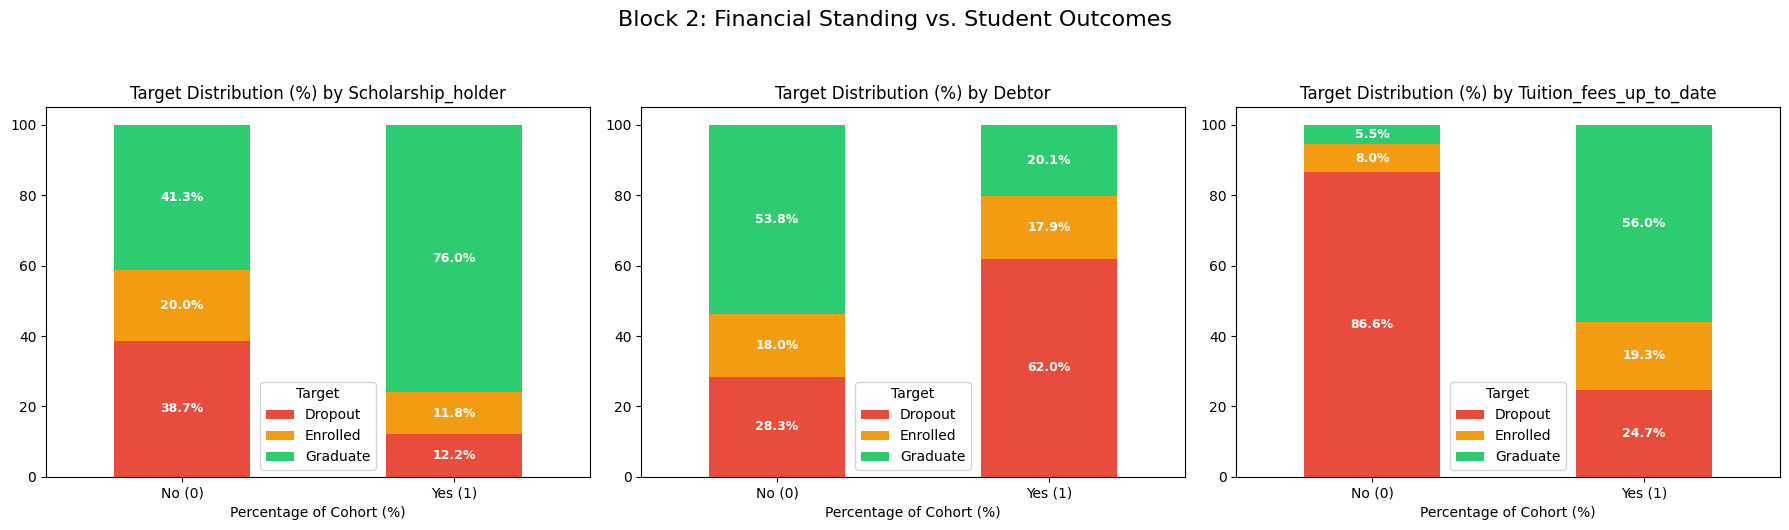

In [24]:
financial_features = ['Scholarship_holder', 'Debtor', 'Tuition_fees_up_to_date']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(financial_features):
    crosstab = pd.crosstab(data[col], data['Target'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=['#e74c3c', '#f39c12', '#2ecc71'])
    axes[i].set_title(f'Outcome Ratio by {col}')
    axes[i].set_ylabel('% of Students')
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    for container in axes[i].containers:
        labels = [f'{val.get_height():.1f}%' if val.get_height() > 2.0 else '' for val in container]
        axes[i].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=9)
    axes[i].set_title(f'Target Distribution (%) by {col}')
    axes[i].set_xlabel('Percentage of Cohort (%)')
    axes[i].set_ylabel('')
plt.suptitle("Block 2: Financial Standing vs. Student Outcomes", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

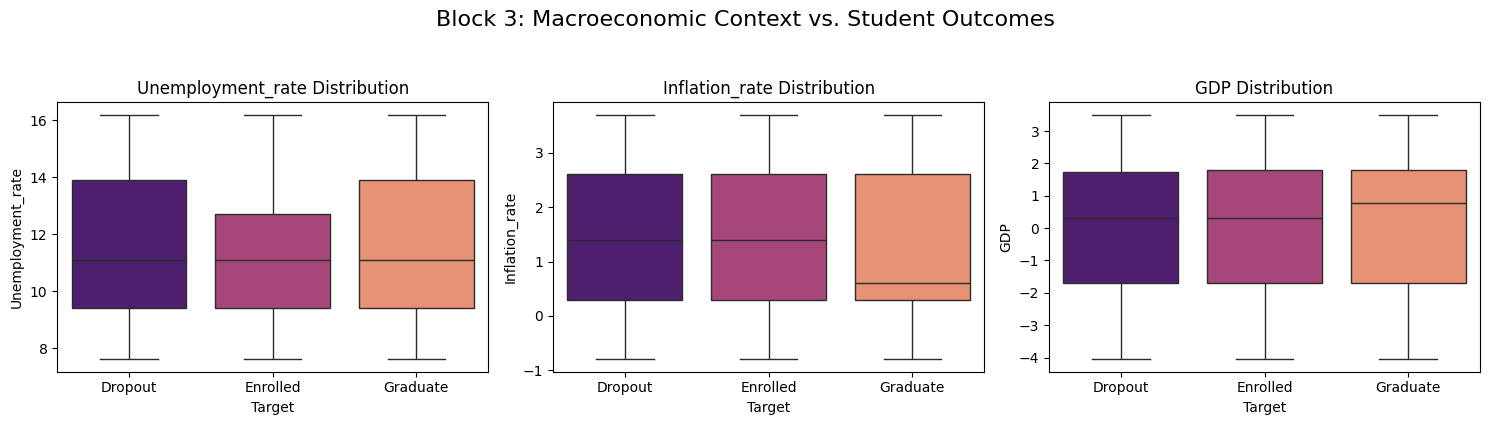

In [25]:
macro_features = ['Unemployment_rate', 'Inflation_rate', 'GDP']
plt.figure(figsize=(15, 4))

for i, col in enumerate(macro_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Target', y=col, hue='Target', data=data, palette='magma', legend=False)
    plt.title(f'{col} Distribution')

plt.suptitle("Block 3: Macroeconomic Context vs. Student Outcomes", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

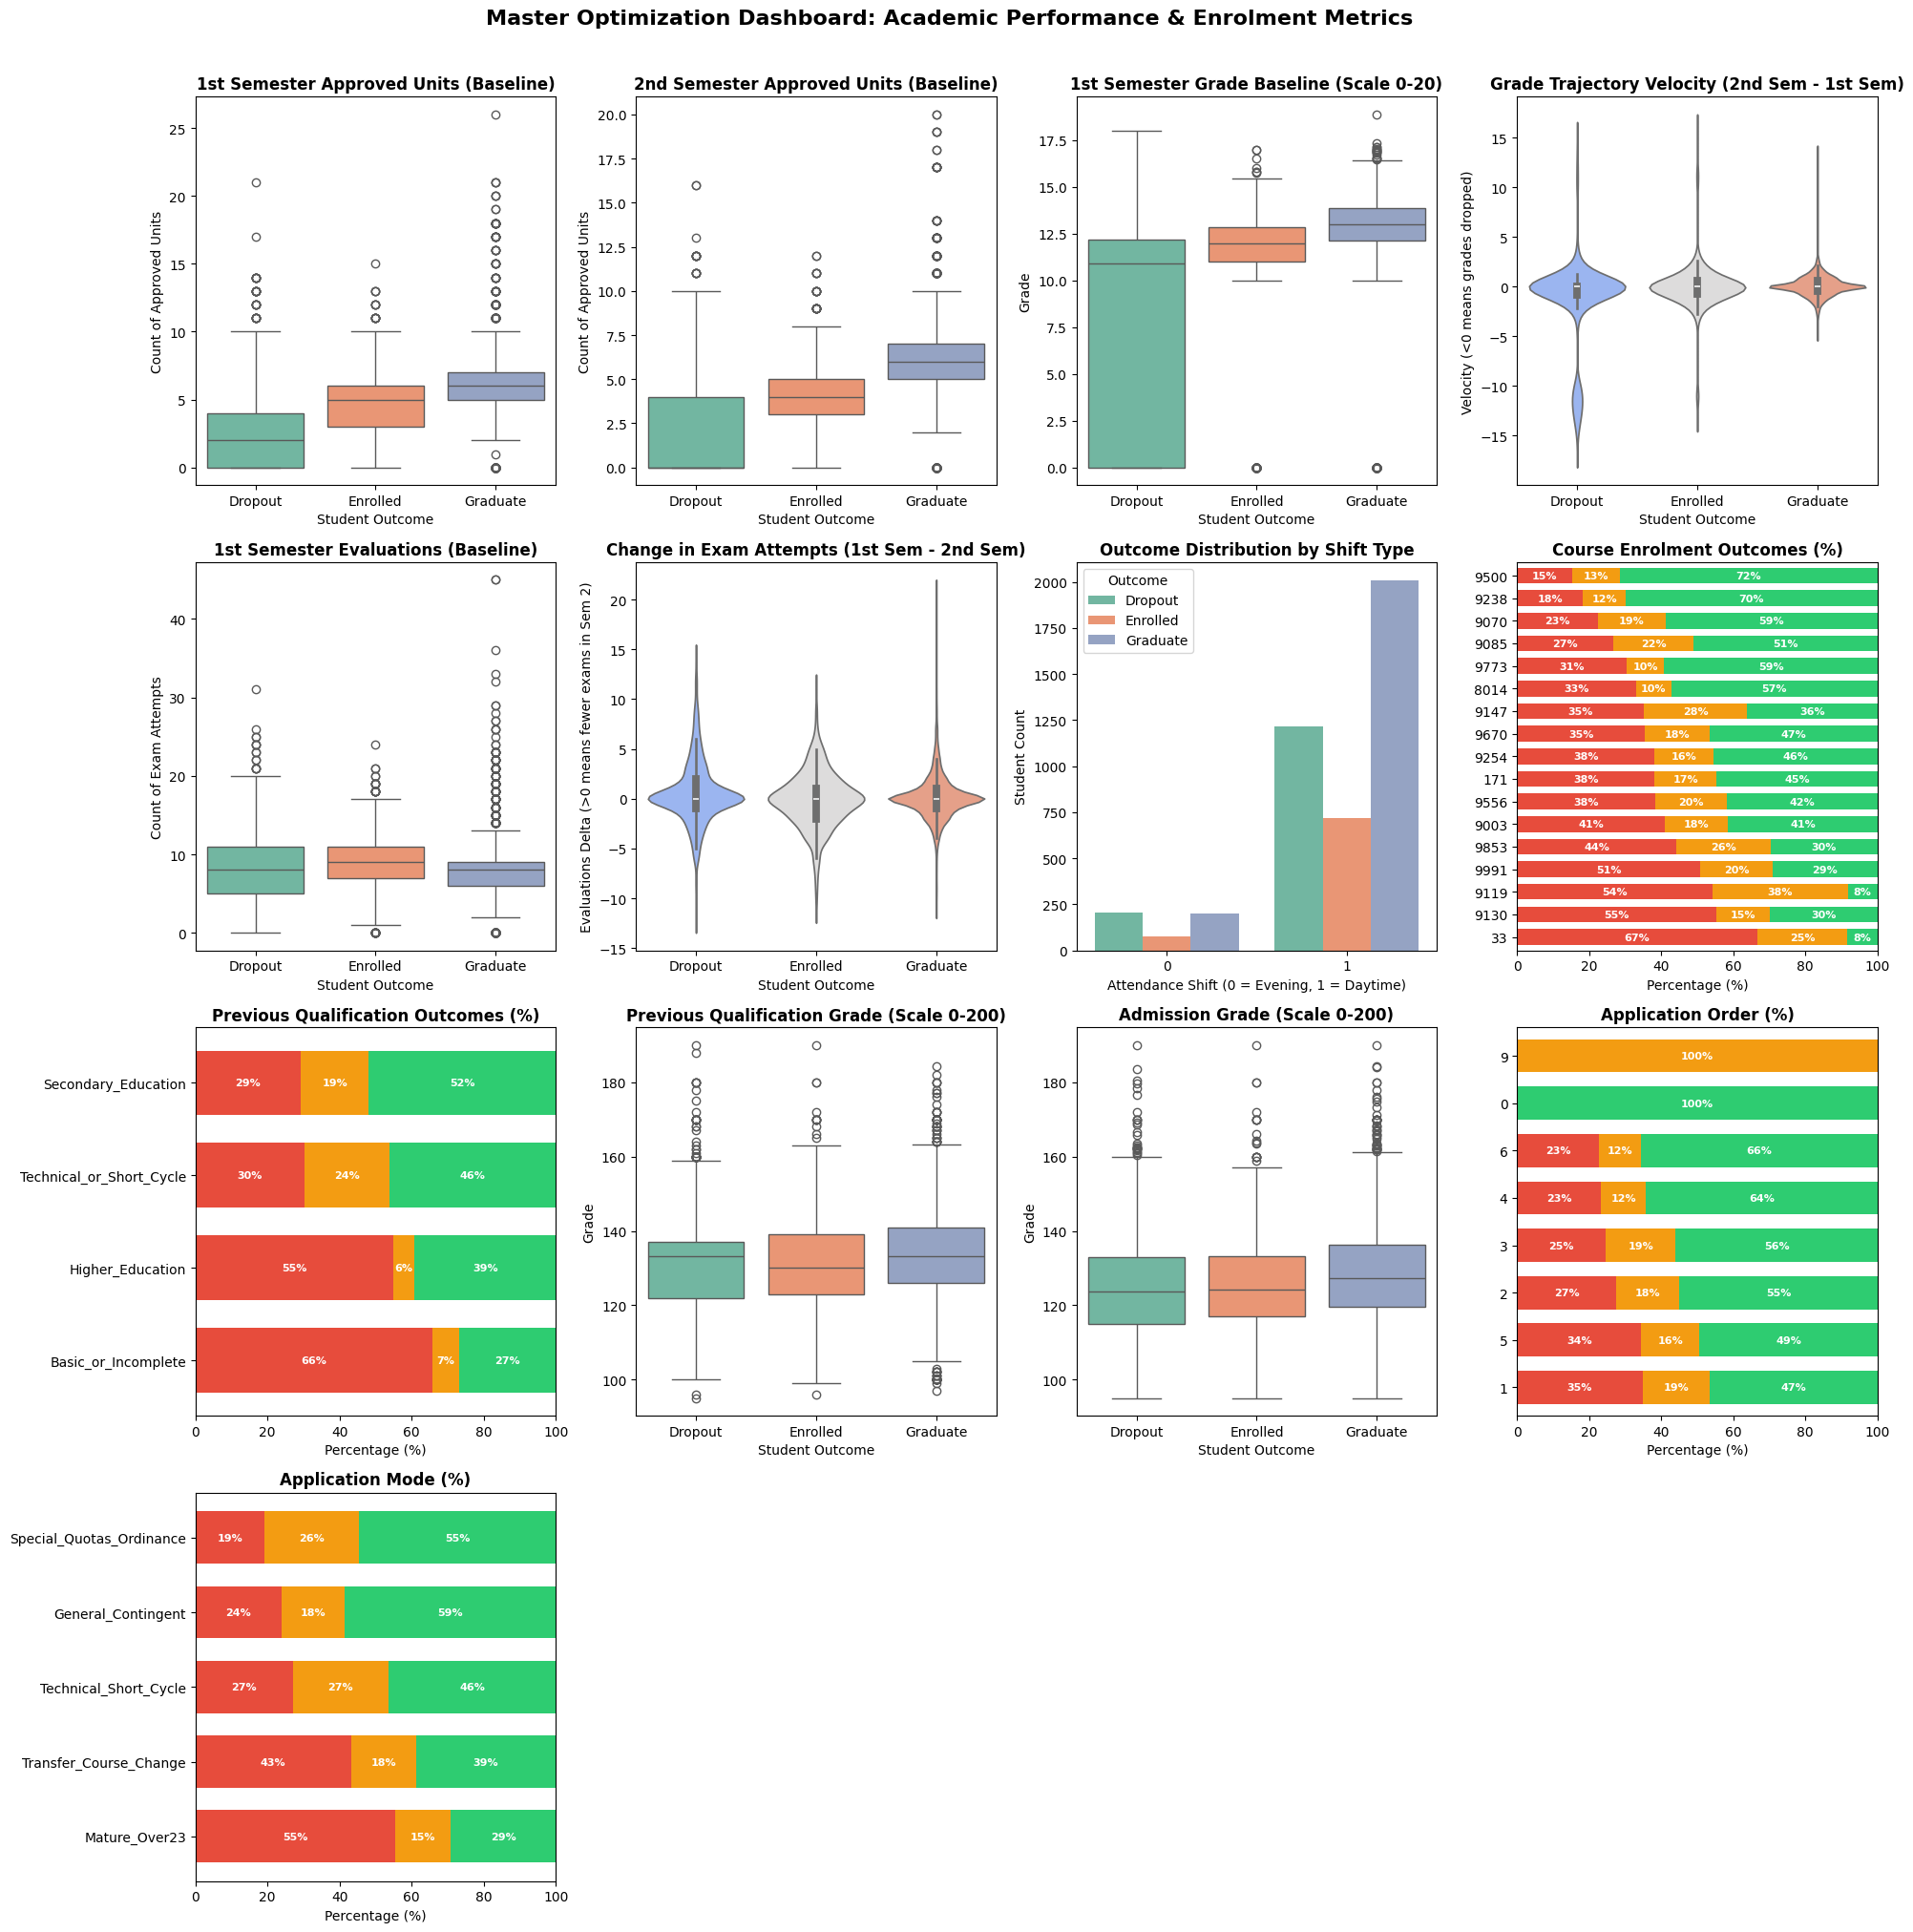

In [26]:
fig, axes = plt.subplots(4,4, figsize=(20, 20))
axes = axes.flatten()

target_col = 'Target' 
colors = ['#e74c3c', '#f39c12', '#2ecc71'] 

sns.boxplot(x=target_col, y='Curricular_units_1st_sem_approved', hue=target_col, data=data, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('1st Semester Approved Units (Baseline)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Student Outcome')
axes[0].set_ylabel('Count of Approved Units')

sns.boxplot(x=target_col, y='Curricular_units_2nd_sem_approved', hue=target_col, data=data, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('2nd Semester Approved Units (Baseline)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Student Outcome')
axes[1].set_ylabel('Count of Approved Units')

sns.boxplot(x=target_col, y='Curricular_units_1st_sem_grade', hue=target_col, data=data, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('1st Semester Grade Baseline (Scale 0-20)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Student Outcome')
axes[2].set_ylabel('Grade')

sns.violinplot(x=target_col, y='Grade_Trajectory', hue=target_col, data=data, ax=axes[3], palette='coolwarm', legend=False)
axes[3].set_title('Grade Trajectory Velocity (2nd Sem - 1st Sem)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Student Outcome')
axes[3].set_ylabel('Velocity (<0 means grades dropped)')

sns.boxplot(x=target_col, y='Curricular_units_1st_sem_evaluations', hue=target_col, data=data, ax=axes[4], palette='Set2', legend=False)
axes[4].set_title('1st Semester Evaluations (Baseline)', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Student Outcome')
axes[4].set_ylabel('Count of Exam Attempts')

sns.violinplot(x=target_col, y='Evaluations_Delta', hue=target_col, data=data, ax=axes[5], palette='coolwarm', legend=False)
axes[5].set_title('Change in Exam Attempts (1st Sem - 2nd Sem)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Student Outcome')
axes[5].set_ylabel('Evaluations Delta (>0 means fewer exams in Sem 2)')

sns.countplot(x='Daytime/evening', hue=target_col, data=data, ax=axes[6], palette='Set2')
axes[6].set_title('Outcome Distribution by Shift Type', fontsize=12, fontweight='bold')
axes[6].set_xlabel('Attendance Shift (0 = Evening, 1 = Daytime)')
axes[6].set_ylabel('Student Count')
axes[6].legend(title='Outcome', loc='upper left')

course_ct = pd.crosstab(data['Course'], data[target_col], normalize='index') * 100
course_ct = course_ct.sort_values(by=course_ct.columns[0], ascending=False)
course_ct.plot(kind='barh', stacked=True, ax=axes[7], color=colors[:len(course_ct.columns)], width=0.7)
axes[7].set_title('Course Enrolment Outcomes (%)', fontsize=12, fontweight='bold')
axes[7].set_xlabel('Percentage (%)')
axes[7].set_ylabel('')
axes[7].set_xlim(0, 100)
axes[7].get_legend().remove() 

for container in axes[7].containers:
    labels = [f'{val.get_width():.0f}%' if val.get_width() > 5.0 else '' for val in container]
    axes[7].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=8)

qual_ct = pd.crosstab(data['Previous_qualification_grouped'], data[target_col], normalize='index') * 100
qual_ct = qual_ct.sort_values(by=qual_ct.columns[0], ascending=False)
qual_ct.plot(kind='barh', stacked=True, ax=axes[8], color=colors[:len(qual_ct.columns)], width=0.7)
axes[8].set_title('Previous Qualification Outcomes (%)', fontsize=12, fontweight='bold')
axes[8].set_xlabel('Percentage (%)')
axes[8].set_ylabel('')
axes[8].set_xlim(0, 100)
axes[8].get_legend().remove()

for container in axes[8].containers:
    labels = [f'{val.get_width():.0f}%' if val.get_width() > 5.0 else '' for val in container]
    axes[8].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=8)

sns.boxplot(x=target_col, y='Previous_qualification_grade', hue=target_col, data=data, ax=axes[9], palette='Set2', legend=False)
axes[9].set_title('Previous Qualification Grade (Scale 0-200)', fontsize=12, fontweight='bold')
axes[9].set_xlabel('Student Outcome')
axes[9].set_ylabel('Grade')

sns.boxplot(x=target_col, y='Admission_grade', hue=target_col, data=data, ax=axes[10], palette='Set2', legend=False)
axes[10].set_title('Admission Grade (Scale 0-200)', fontsize=12, fontweight='bold')
axes[10].set_xlabel('Student Outcome')
axes[10].set_ylabel('Grade')

order_ct = pd.crosstab(data['Application_order'], data[target_col], normalize='index') * 100
order_ct = order_ct.sort_values(by=order_ct.columns[0], ascending=False)
order_ct.plot(kind='barh', stacked=True, ax=axes[11], color=colors[:len(order_ct.columns)], width=0.7)
axes[11].set_title('Application Order (%)', fontsize=12, fontweight='bold')
axes[11].set_xlabel('Percentage (%)')
axes[11].set_ylabel('')
axes[11].set_xlim(0, 100)
axes[11].get_legend().remove()

for container in axes[11].containers:
    labels = [f'{val.get_width():.0f}%' if val.get_width() > 5.0 else '' for val in container]
    axes[11].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=8)

mode_ct = pd.crosstab(data['Application_mode_grouped'], data[target_col], normalize='index') * 100
mode_ct = mode_ct.sort_values(by=mode_ct.columns[0], ascending=False)
mode_ct.plot(kind='barh', stacked=True, ax=axes[12], color=colors[:len(mode_ct.columns)], width=0.7)
axes[12].set_title('Application Mode (%)', fontsize=12, fontweight='bold')
axes[12].set_xlabel('Percentage (%)')
axes[12].set_ylabel('')
axes[12].set_xlim(0, 100)
axes[12].get_legend().remove()

for container in axes[12].containers:
    labels = [f'{val.get_width():.0f}%' if val.get_width() > 5.0 else '' for val in container]
    axes[12].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=8)

axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle("Master Optimization Dashboard: Academic Performance & Enrolment Metrics", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

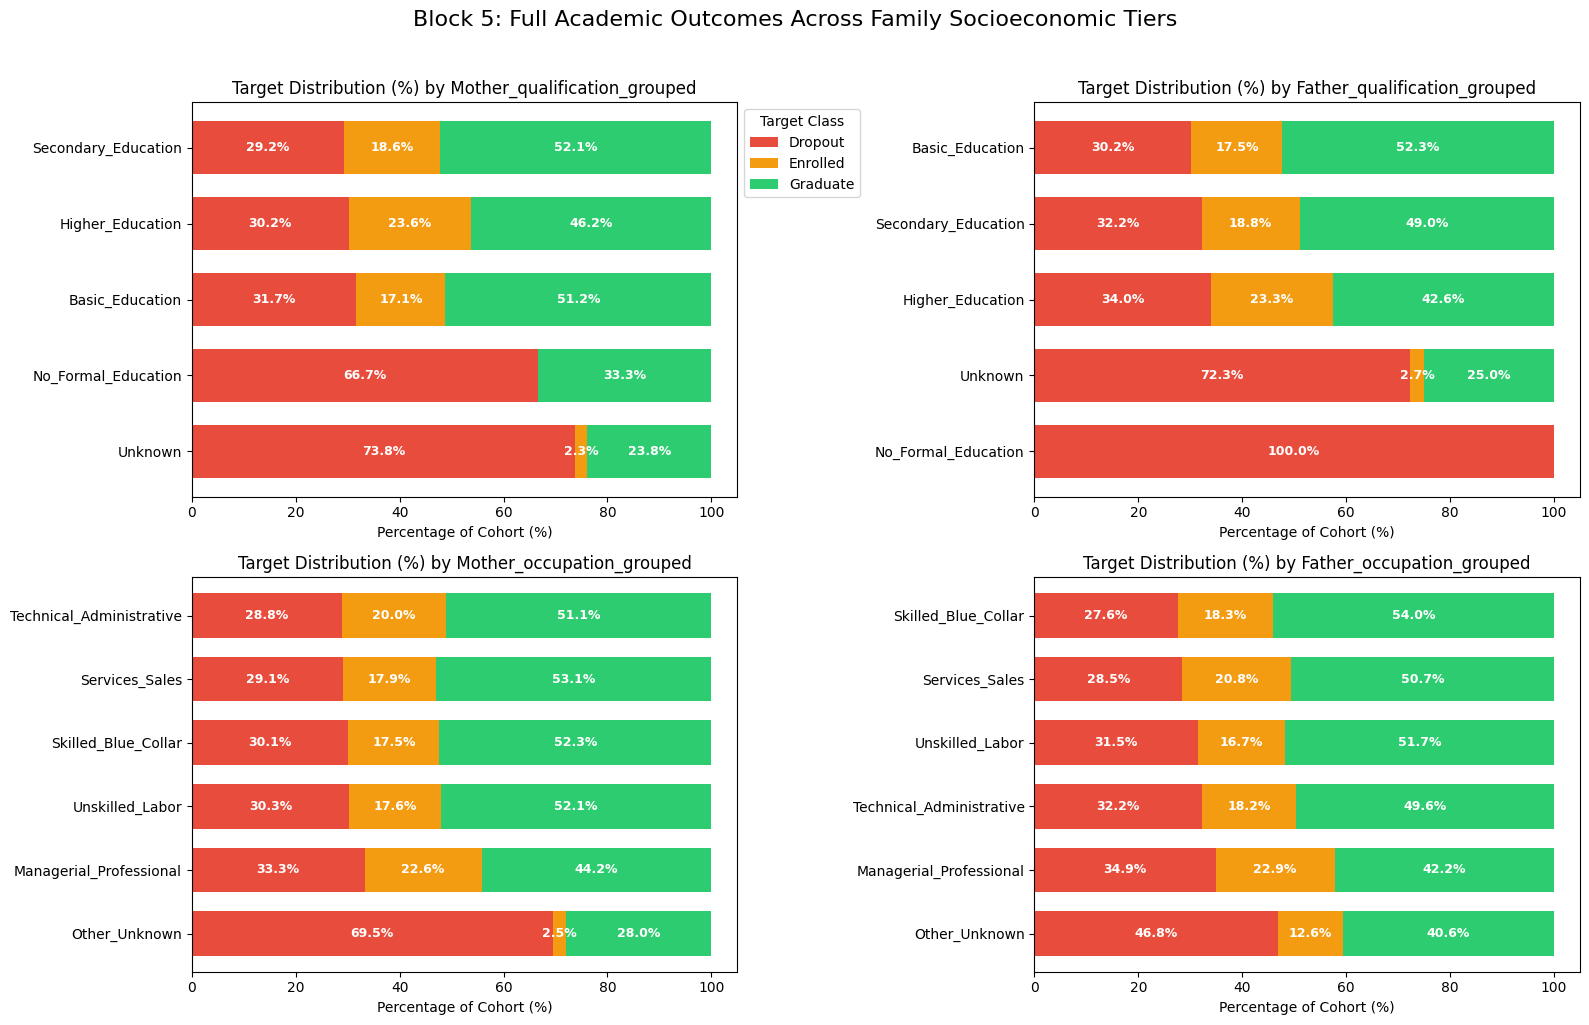

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

parent_features = ['Mother_qualification_grouped', 'Father_qualification_grouped', 
                   'Mother_occupation_grouped', 'Father_occupation_grouped']

colors = ['#e74c3c', '#f39c12', '#2ecc71'] 

for i, col in enumerate(parent_features):
    # Create a cross-tabulation table and normalize it by row (index) to get percentages
    crosstab = pd.crosstab(data[col], data['Target'], normalize='index') * 100
    
    dropout_col = 'Dropout' if 'Dropout' in crosstab.columns else crosstab.columns[0]
    crosstab = crosstab.sort_values(by=dropout_col, ascending=False)
    
    
    crosstab.plot(
        kind='barh',
        stacked=True, 
        ax=axes[i], 
        color=colors[:len(crosstab.columns)],
        width=0.7
    )
    for container in axes[i].containers:
        # Only display the label if the segment is wider than 2%
        labels = [f'{val.get_width():.1f}%' if val.get_width() > 2.0 else '' for val in container]
        axes[i].bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=9)
    axes[i].set_title(f'Target Distribution (%) by {col}')
    axes[i].set_xlabel('Percentage of Cohort (%)')
    axes[i].set_ylabel('')
    
    # Only keep the legend box on the final plot to prevent layout clutter
    if i == 0:
        axes[i].legend(title='Target Class', loc='upper left', bbox_to_anchor=(1, 1))
    else:
        axes[i].get_legend().remove()

plt.suptitle("Block 5: Full Academic Outcomes Across Family Socioeconomic Tiers", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Filter features
data_final = data.drop(columns=['International', 'Educational_special_needs', 'Nationality','Curricular_units_1st_sem_credited', 
                                'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 
                                'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations'], axis=1)
data_final.head()

,Marital_status,Application_order,Course,Daytime/evening,Previous_qualification_grade,Admission_grade,Displaced,Debtor,Tuition_fees_up_to_date,Gender,...,GDP,Target,Father_qualification_grouped,Mother_qualification_grouped,Previous_qualification_grouped,Mother_occupation_grouped,Father_occupation_grouped,Application_mode_grouped,Grade_Trajectory,Evaluations_Delta
0,1,5,171,1,122.0,127.3,1,0,1,1,...,1.74,Dropout,Secondary_Education,Basic_Education,Secondary_Education,Services_Sales,Unskilled_Labor,General_Contingent,0.000000,0
1,1,1,9254,1,160.0,142.5,1,0,0,1,...,0.79,Graduate,Higher_Education,Secondary_Education,Secondary_Education,Technical_Administrative,Technical_Administrative,Special_Quotas_Ordinance,-0.333333,0
2,1,5,9070,1,122.0,124.8,1,0,0,1,...,1.74,Dropout,Basic_Education,Basic_Education,Secondary_Education,Unskilled_Labor,Unskilled_Labor,General_Contingent,0.000000,0
3,1,2,9773,1,122.0,119.6,1,0,1,0,...,-3.12,Graduate,Basic_Education,Basic_Education,Secondary_Education,Services_Sales,Technical_Administrative,General_Contingent,-1.028571,-2
4,2,1,8014,0,100.0,141.5,0,0,1,0,...,0.79,Graduate,Basic_Education,Basic_Education,Secondary_Education,Unskilled_Labor,Unskilled_Labor,Mature_Over23,0.666667,3


In [29]:
# Initialize and transform the target column directly
le = LabelEncoder()
data_final['Target'] = le.fit_transform(data_final['Target'])

print("Target Class Mapping:")
for index, label in enumerate(le.classes_):
    print(f"   {index} = {label}")

Target Class Mapping:
   0 = Dropout
   1 = Enrolled
   2 = Graduate


In [30]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Marital_status                        4424 non-null   category
 1   Application_order                     4424 non-null   category
 2   Course                                4424 non-null   category
 3   Daytime/evening                       4424 non-null   category
 4   Previous_qualification_grade          4424 non-null   float64 
 5   Admission_grade                       4424 non-null   float64 
 6   Displaced                             4424 non-null   category
 7   Debtor                                4424 non-null   category
 8   Tuition_fees_up_to_date               4424 non-null   category
 9   Gender                                4424 non-null   category
 10  Scholarship_holder                    4424 non-null   category
 11  Age 

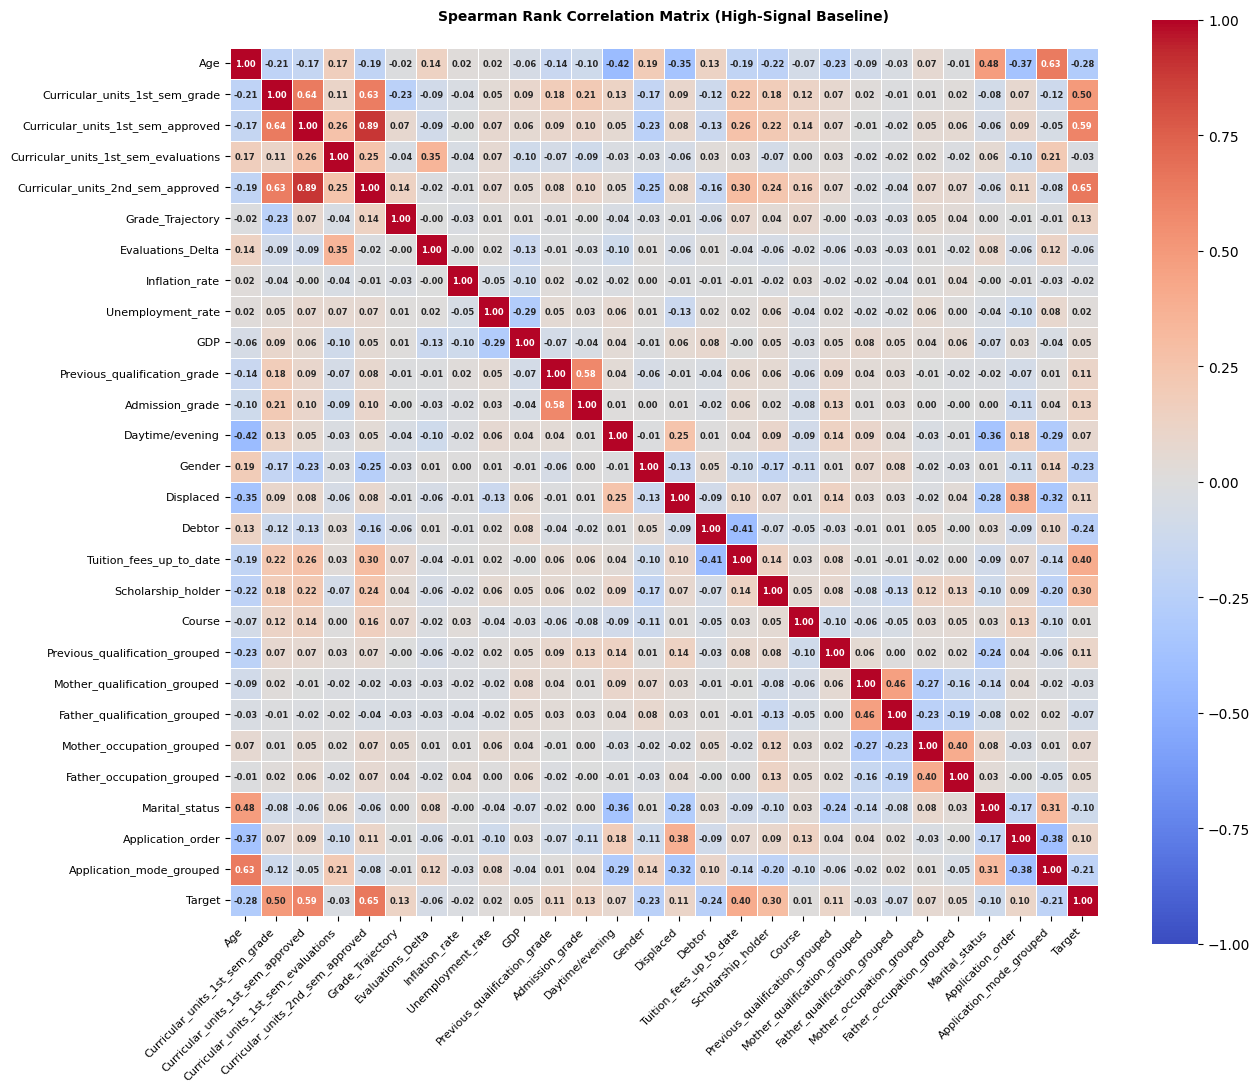

In [31]:
# 1. Define features
core_numeric_features = [
    'Age', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_2nd_sem_approved', 'Grade_Trajectory', 'Evaluations_Delta',
    'Inflation_rate', 'Unemployment_rate', 'GDP', 'Previous_qualification_grade', 'Admission_grade'
]

# Explicitly separate the binary features
binary_features = ['Daytime/evening', 'Gender', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder']

# High-cardinality categorical features that actually need one-hot encoding
multiclass_categorical = [
    'Course', 'Previous_qualification_grouped', 'Mother_qualification_grouped', 
    'Father_qualification_grouped', 'Mother_occupation_grouped', 'Father_occupation_grouped', 
    'Marital_status', 'Application_order', 'Application_mode_grouped'
]

matrix_cols = core_numeric_features + binary_features + multiclass_categorical + ['Target']
corr_data = data[matrix_cols].copy()

# 2. Convert text columns to codes for the correlation matrix
for col in binary_features + multiclass_categorical + ['Target']:
    corr_data[col] = corr_data[col].astype('category').cat.codes

# 3. Compute Spearman Rank Correlation
spearman_matrix = corr_data.corr(method='spearman')

# 4. Plot Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    spearman_matrix, 
    cmap='coolwarm', 
    vmax=1.0, vmin=-1.0, 
    annot=True,          
    fmt=".2f",           
    annot_kws={"size": 6, "fontweight": "bold"}, 
    square=True,
    linewidths=0.5       
)
plt.title("Spearman Rank Correlation Matrix (High-Signal Baseline)", fontsize=10, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.show()

One-hot-encoding for categorical features

In [32]:
# First, ensure your binary features are strictly numeric 0 and 1 in data_final
for col in binary_features:
    if data_final[col].dtype == 'object' or isinstance(data_final[col].dtype, pd.CategoricalDtype):
        data_final[col] = data_final[col].astype('category').cat.codes

# Identify all object/category columns for one-hot encoding
to_one_hot = data_final.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude Target and all Binary features from the one-hot list
features_to_exclude = ['Target'] + binary_features
to_one_hot = [col for col in to_one_hot if col not in features_to_exclude]

print(f"Found categorical features to one-hot encode: {to_one_hot}")
print(f"Kept as binary numeric (0/1): {binary_features}")

# Automatically expand ONLY the remaining multi-class categorical columns
data_one_hot = pd.get_dummies(data_final, columns=to_one_hot, drop_first=True, dtype=int)

print(f"Conversion complete! New dataframe shape: {data_one_hot.shape}")

Found categorical features to one-hot encode: ['Marital_status', 'Application_order', 'Course', 'Father_qualification_grouped', 'Mother_qualification_grouped', 'Previous_qualification_grouped', 'Mother_occupation_grouped', 'Father_occupation_grouped', 'Application_mode_grouped']
Kept as binary numeric (0/1): ['Daytime/evening', 'Gender', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder']
Conversion complete! New dataframe shape: (4424, 72)


In [33]:
# Isolate X and y
X = data_one_hot.drop(columns=['Target'])
y = data_one_hot['Target']

# Split into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Convert train sets to integer
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)
print(f"Data partitioned! Training shapes: X={X_train_scaled.shape}, y={y_train.shape}")

Data partitioned! Training shapes: X=(3539, 71), y=(3539,)


📊 PCA Explained Variance per Component: [0.06547207 0.04911638 0.04411821]
📈 Total variance captured by 3 Principal Components: 15.9%



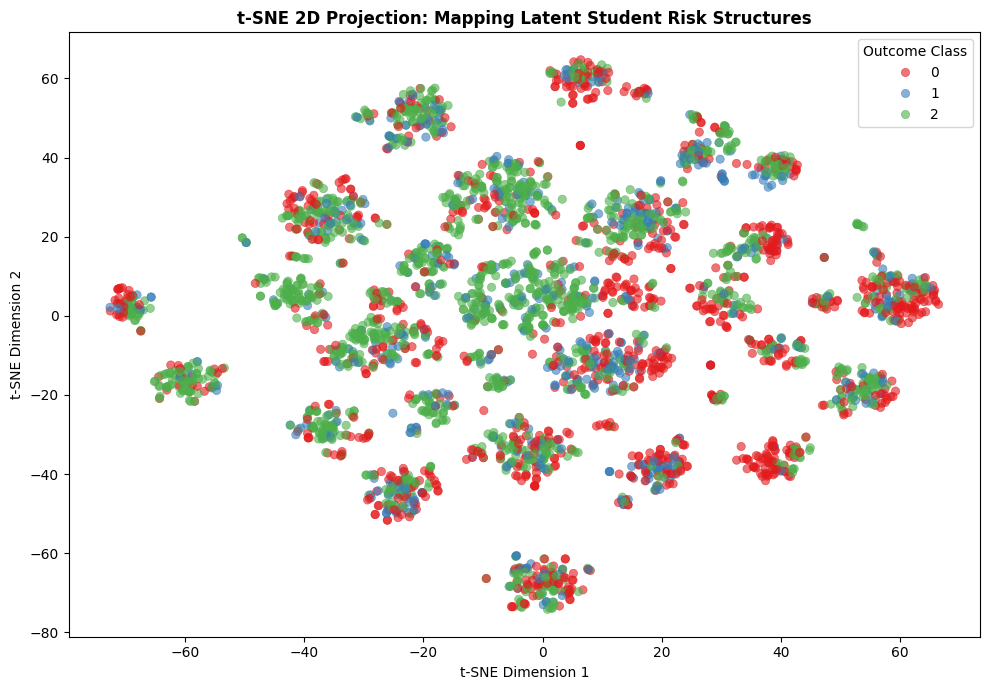

In [34]:
# PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"📊 PCA Explained Variance per Component: {pca.explained_variance_ratio_}")
print(f"📈 Total variance captured by 3 Principal Components: {np.sum(pca.explained_variance_ratio_)*100:.1f}%\n")

# t-SNE visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_train_scaled)

# Plotting the 2D Cluster Map
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_train_int,
    palette='Set1',
    alpha=0.6,
    edgecolor=None
)
plt.title('t-SNE 2D Projection: Mapping Latent Student Risk Structures', fontsize=12, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Outcome Class')
plt.tight_layout()
plt.show()

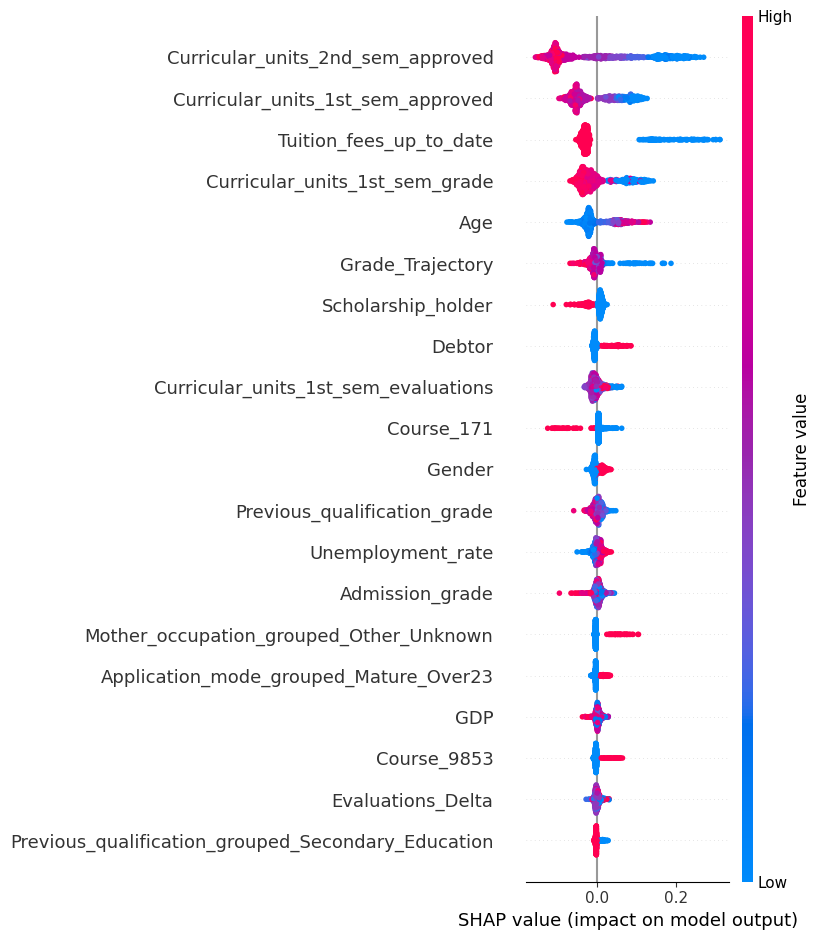

In [35]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_int)

# Initialize Tree Explainer
explainer = shap.TreeExplainer(rf_model)

# Extract SHAP values from the test set
shap_values = explainer.shap_values(X_test_scaled)

# Generate summary plot for Class 0 (Dropout) using 3D array slicing
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    class_0_shap = shap_values[:, :, 0]
else:
    class_0_shap = shap_values[0]

# Generate the plot
shap.summary_plot(
    class_0_shap, 
    X_test_scaled.values, 
    feature_names=X_test_scaled.columns
)

MODEL PERFORMANCE REPORT:

              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.58      0.33      0.42       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



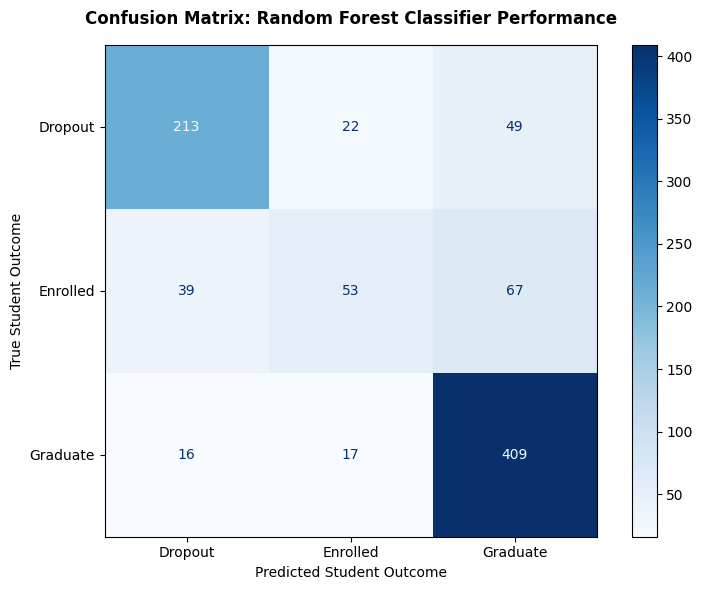

In [36]:
# Generate predictions on the scaled test set
y_pred = rf_model.predict(X_test_scaled)

# Print the comprehensive classification report
print("MODEL PERFORMANCE REPORT:\n")
# target_names maps directly to your LabelEncoder mapping (0=Dropout, 1=Enrolled, 2=Graduate)
print(classification_report(y_test_int, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot the confusion matrix
cm = confusion_matrix(y_test_int, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Dropout', 'Enrolled', 'Graduate']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Random Forest Classifier Performance', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Student Outcome')
plt.ylabel('True Student Outcome')
plt.tight_layout()
plt.show()

Calculated Class Imbalance Ratio: 1.79

XGBOOST PERFORMANCE REPORT:

              precision    recall  f1-score   support

     Dropout       0.79      0.70      0.74       284
    Enrolled       0.50      0.36      0.42       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.66      0.67       885
weighted avg       0.74      0.75      0.74       885



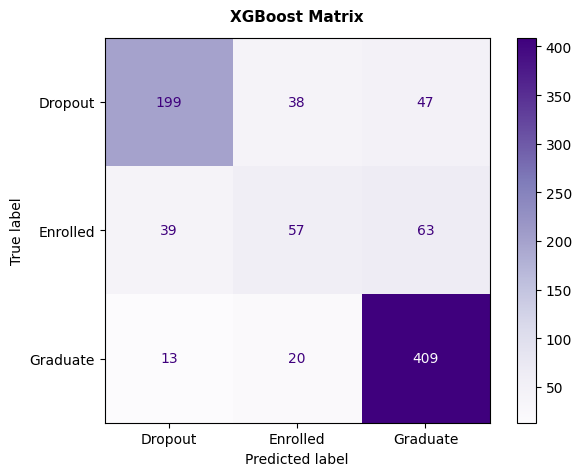

In [37]:
# Calculate the imbalance ratio
# Formula: number of negative samples (Safe) / number of positive samples (Risk)
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
imbalance_ratio = neg_count / pos_count

print(f"Calculated Class Imbalance Ratio: {imbalance_ratio:.2f}")

# Initialize the XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,      
    max_depth=4,              
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'     
)

xgb.fit(X_train_scaled, y_train_int)

# Predict and evaluate
y_pred_xgb = xgb.predict(X_test_scaled)

print("\nXGBOOST PERFORMANCE REPORT:\n")
print(classification_report(y_test_int, y_pred_xgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot the confusion matrix
cm_xgb = confusion_matrix(y_test_int, y_pred_xgb)
fig, ax = plt.subplots(figsize=(7, 5))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp_xgb.plot(cmap='Purples', ax=ax, values_format='d')
plt.title('XGBoost Matrix', fontsize=11, fontweight='bold', pad=12)
plt.show()


LIGHTGBM BINARY PERFORMANCE REPORT:

              precision    recall  f1-score   support

     Dropout       0.77      0.71      0.74       284
    Enrolled       0.48      0.34      0.40       159
    Graduate       0.79      0.91      0.85       442

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.75      0.73       885



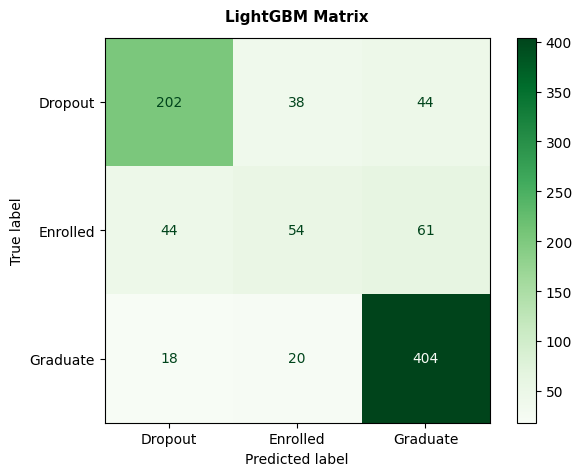

In [38]:
# Initialize the LightGBM Classifier
lgb = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,             
    is_unbalance=True,         
    random_state=42,
    n_jobs=-1,
    verbose=-1                 
)

lgb.fit(X_train_scaled, y_train_int)

# Predict and evaluate
y_pred_lgb = lgb.predict(X_test_scaled)

print("\nLIGHTGBM BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_int, y_pred_lgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot the confusion matrix
cm_lgb = confusion_matrix(y_test_int, y_pred_lgb)
fig, ax = plt.subplots(figsize=(7, 5))
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp_lgb.plot(cmap='Greens', ax=ax, values_format='d') 
plt.title('LightGBM Matrix', fontsize=11, fontweight='bold', pad=12)
plt.show()

SVC training phase complete!

SVC PERFORMANCE REPORT:

              precision    recall  f1-score   support

     Dropout       0.79      0.65      0.72       284
    Enrolled       0.40      0.54      0.46       159
    Graduate       0.83      0.82      0.83       442

    accuracy                           0.72       885
   macro avg       0.67      0.67      0.67       885
weighted avg       0.74      0.72      0.72       885



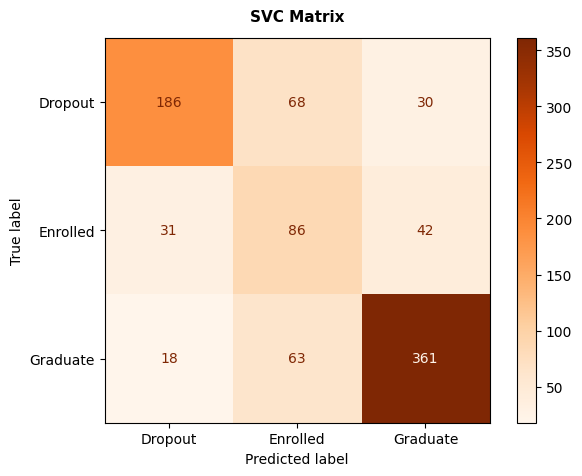

In [39]:
# Initialize the SVC
svc = SVC(
    kernel='rbf',
    C=1.0,                       
    gamma='scale',               
    class_weight='balanced',     
    probability=True,            
    random_state=42
)

svc.fit(X_train_scaled, y_train_int)
print("SVC training phase complete!")

# Predict and evaluate
y_pred_svc = svc.predict(X_test_scaled)

print("\nSVC PERFORMANCE REPORT:\n")
print(classification_report(y_test_int, y_pred_svc, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot the confusion matrix
cm_svc = confusion_matrix(y_test_int, y_pred_svc)
fig, ax = plt.subplots(figsize=(7, 5))
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp_svc.plot(cmap='Oranges', ax=ax, values_format='d') 
plt.title('SVC Matrix', fontsize=11, fontweight='bold', pad=12)
plt.show()


ENSEMBLE VOTING PERFORMANCE REPORT:

              precision    recall  f1-score   support

     Dropout       0.78      0.71      0.75       284
    Enrolled       0.51      0.35      0.42       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.74      0.75      0.74       885



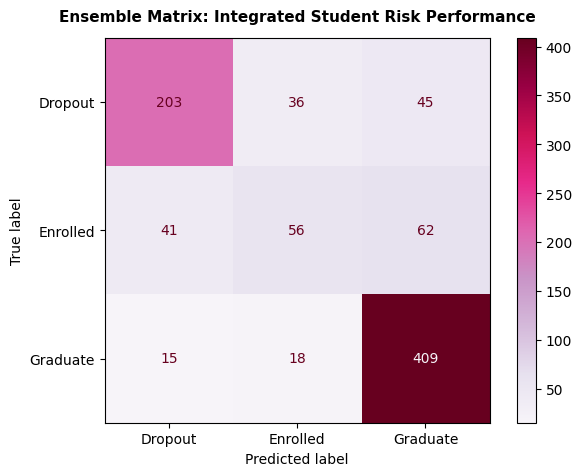

In [40]:
# Compile Random Forest, XGBoost, Light GBM, and SVC
named_estimators = [
    ('random_forest', rf_model),
    ('xgb', xgb),
    ('lightgbm', lgb),
    ('svc', svc)
]

# Initialize the Voting Classifier with 'soft' probabilities
ensemble = VotingClassifier(
    estimators=named_estimators,
    voting='soft', 
    n_jobs=-1
)

ensemble.fit(X_train_scaled, y_train_int)

# Predict and evaluate
y_pred_ensemble = ensemble.predict(X_test_scaled)

print("\nENSEMBLE VOTING PERFORMANCE REPORT:\n")
print(classification_report(y_test_int, y_pred_ensemble, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Plot the confusion matrix
cm_ens = confusion_matrix(y_test_int, y_pred_ensemble)
fig, ax = plt.subplots(figsize=(7, 5))
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['Dropout', 'Enrolled', 'Graduate'])
disp_ens.plot(cmap='PuRd', ax=ax, values_format='d') 
plt.title('Ensemble Matrix: Integrated Student Risk Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()

# Dropout vs Non Dropout

New Binary Distribution Profile:
0    67.88% (Class 1)
1    32.12% (Class 1)
Name: proportion, dtype: object

BINARY MODEL PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.88      0.95      0.91       601
    Risk (Dropout)       0.87      0.73      0.79       284

          accuracy                           0.88       885
         macro avg       0.88      0.84      0.85       885
      weighted avg       0.88      0.88      0.87       885



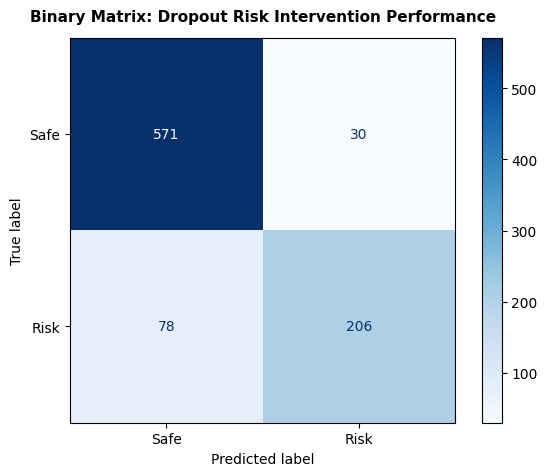

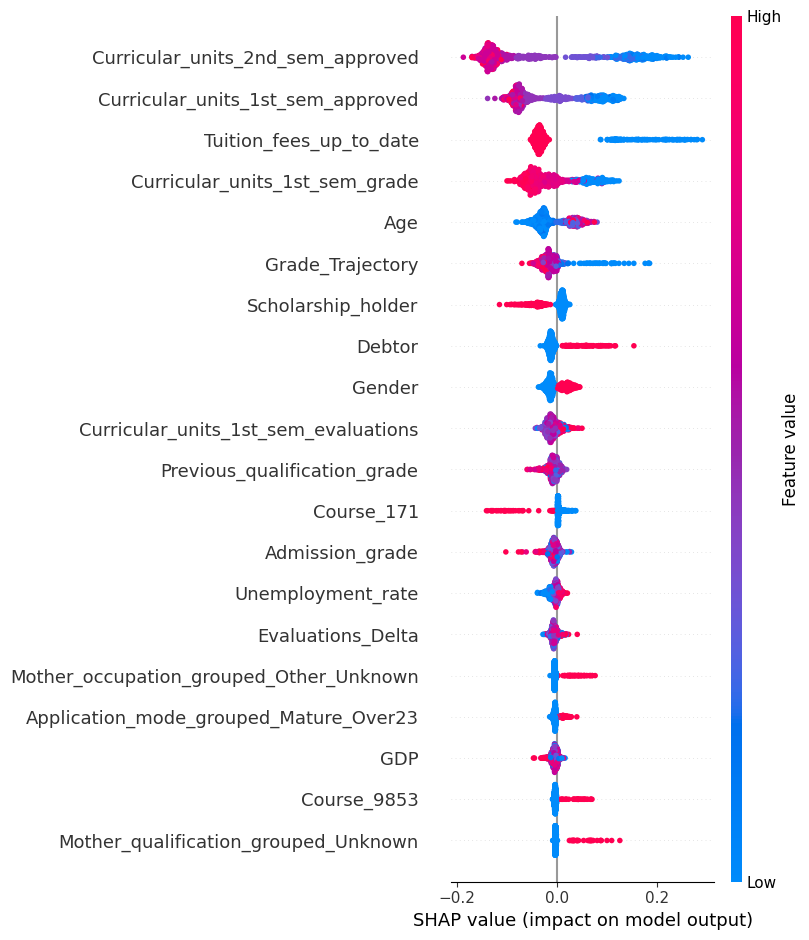

In [41]:
# Mapping rule: If original Target was Dropout (0) -> 1 (Risk Event to Detect)
# If original Target was Enrolled (1) or Graduate (2) -> 0 (Safe / Non-Dropout)
X_bin = data_one_hot.drop(columns=['Target'])
y_bin = np.where(data_one_hot['Target'] == 0, 1, 0)

print("New Binary Distribution Profile:")
print(pd.Series(y_bin).value_counts(normalize=True).map(lambda x: f"{x*100:.2f}% (Class {int(x==x)})"))

# Split into 80% train and 20% test sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Scaler features
scaler_bin = StandardScaler()
X_train_bin_scaled = pd.DataFrame(scaler_bin.fit_transform(X_train_bin), columns=X_train_bin.columns)
X_test_bin_scaled = pd.DataFrame(scaler_bin.transform(X_test_bin), columns=X_test_bin.columns)

# Convert train sets to integer
y_train_bin_int = y_train_bin.astype(int)
y_test_bin_int = y_test_bin.astype(int)

#Initialize the Random Forest Classifier
rf_binary = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_binary.fit(X_train_bin_scaled, y_train_bin_int)

#Predict and evaluate
y_pred_bin = rf_binary.predict(X_test_bin_scaled)

print("\nBINARY MODEL PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_bin = confusion_matrix(y_test_bin_int, y_pred_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['Safe', 'Risk'])
disp_bin.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Binary Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()

# Initialize Tree Explainer
explainer_bin = shap.TreeExplainer(rf_binary)

# Extract SHAP values from the test set
shap_values_bin = explainer_bin.shap_values(X_test_bin_scaled)

# Generate summary plot for Class 0 (Dropout) using 3D array slicing
if isinstance(shap_values_bin, np.ndarray) and len(shap_values_bin.shape) == 3:
    risk_shap_values = shap_values_bin[:, :, 1]
else:
    risk_shap_values = shap_values_bin

# Generate the plot
shap.summary_plot(
    risk_shap_values, 
    X_test_bin_scaled.values, 
    feature_names=X_test_bin_scaled.columns
)

PCA Explained Variance per Component: [0.06428999 0.04962296 0.04464724]
Total variance captured by 3 Principal Components: 15.9%



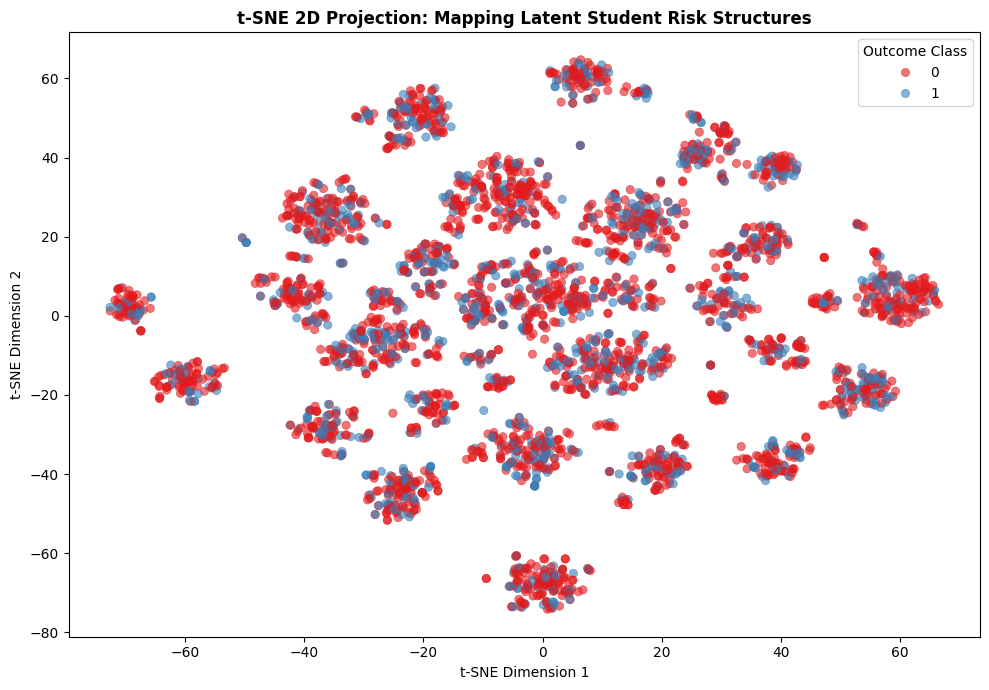

In [42]:
# PCA
pca = PCA(n_components=3)
X_train_bin_pca = pca.fit_transform(X_train_bin_scaled)

print(f"PCA Explained Variance per Component: {pca.explained_variance_ratio_}")
print(f"Total variance captured by 3 Principal Components: {np.sum(pca.explained_variance_ratio_)*100:.1f}%\n")

# t-SNE Visualisation
tsne_bin = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_bin = tsne.fit_transform(X_train_bin_scaled)

# Plotting the 2D Cluster Map
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_train_bin_int,
    palette='Set1',
    alpha=0.6,
    edgecolor=None
)
plt.title('t-SNE 2D Projection: Mapping Latent Student Risk Structures', fontsize=12, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Outcome Class')
plt.tight_layout()
plt.show()

Calculated Class Imbalance Ratio: 2.11

XGBOOST BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.90      0.90       601
    Risk (Dropout)       0.79      0.82      0.80       284

          accuracy                           0.87       885
         macro avg       0.85      0.86      0.85       885
      weighted avg       0.87      0.87      0.87       885



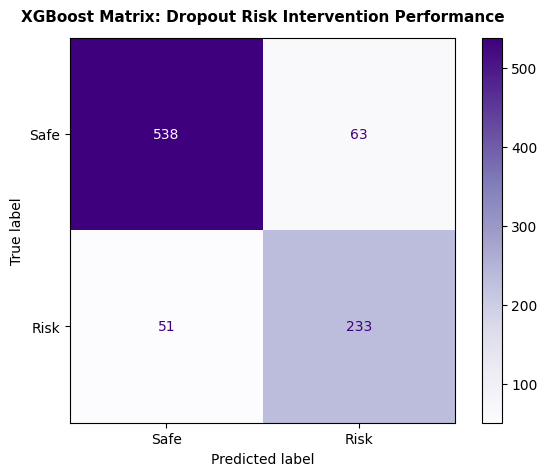

In [43]:
# Calculate the imbalance ratio
# Formula: number of negative samples (Safe) / number of positive samples (Risk)
neg_count = np.sum(y_train_bin == 0)
pos_count = np.sum(y_train_bin == 1)
imbalance_ratio = neg_count / pos_count

print(f"Calculated Class Imbalance Ratio: {imbalance_ratio:.2f}")

# Initialize the XGBoost Classifier
xgb_binary = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,       
    max_depth=4,              
    scale_pos_weight=imbalance_ratio,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'    
)

xgb_binary.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_xgb_bin = xgb_binary.predict(X_test_bin_scaled)

print("\nXGBOOST BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_xgb_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_xgb = confusion_matrix(y_test_bin_int, y_pred_xgb_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Safe', 'Risk'])
disp_xgb.plot(cmap='Purples', ax=ax, values_format='d')
plt.title('XGBoost Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


LIGHTGBM BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.90      0.90       601
    Risk (Dropout)       0.79      0.81      0.80       284

          accuracy                           0.87       885
         macro avg       0.85      0.85      0.85       885
      weighted avg       0.87      0.87      0.87       885



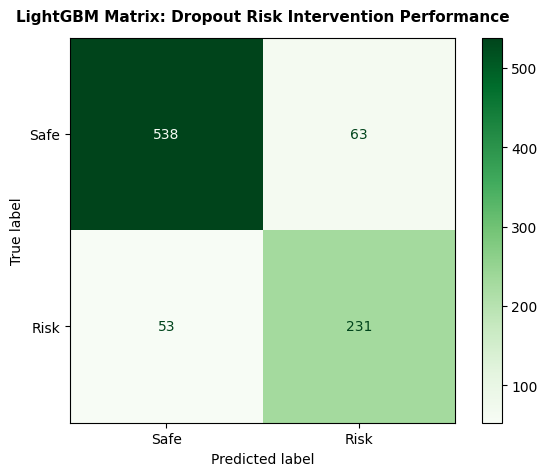

In [44]:
# Initialize the LightGBM Classifier
lgb_binary = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,             
    is_unbalance=True,         
    random_state=42,
    n_jobs=-1,
    verbose=-1                
)

lgb_binary.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_lgb_bin = lgb_binary.predict(X_test_bin_scaled)

print("\nLIGHTGBM BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_lgb_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_lgb = confusion_matrix(y_test_bin_int, y_pred_lgb_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['Safe', 'Risk'])
disp_lgb.plot(cmap='Greens', ax=ax, values_format='d') 
plt.title('LightGBM Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


SVC BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.90      0.90       601
    Risk (Dropout)       0.79      0.80      0.79       284

          accuracy                           0.87       885
         macro avg       0.85      0.85      0.85       885
      weighted avg       0.87      0.87      0.87       885



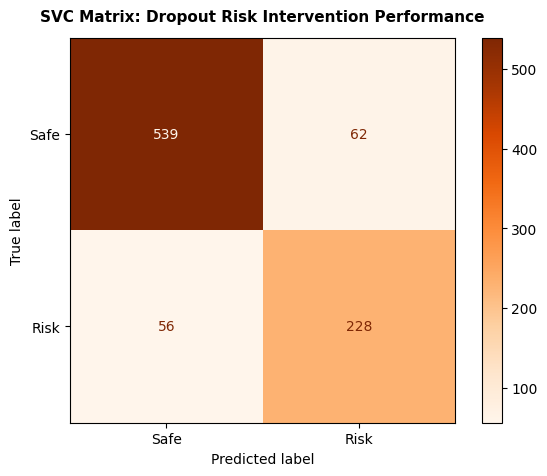

In [45]:
# Initialize the SVC
svc_binary = SVC(
    kernel='rbf',
    C=1.0,                      
    gamma='scale',              
    class_weight='balanced',    
    probability=True,           
    random_state=42
)

svc_binary.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_svc_bin = svc_binary.predict(X_test_bin_scaled)

print("\nSVC BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_svc_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_svc = confusion_matrix(y_test_bin_int, y_pred_svc_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=['Safe', 'Risk'])
disp_svc.plot(cmap='Oranges', ax=ax, values_format='d') 
plt.title('SVC Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


ENSEMBLE VOTING PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.90      0.92      0.91       601
    Risk (Dropout)       0.82      0.79      0.80       284

          accuracy                           0.88       885
         macro avg       0.86      0.85      0.86       885
      weighted avg       0.88      0.88      0.88       885



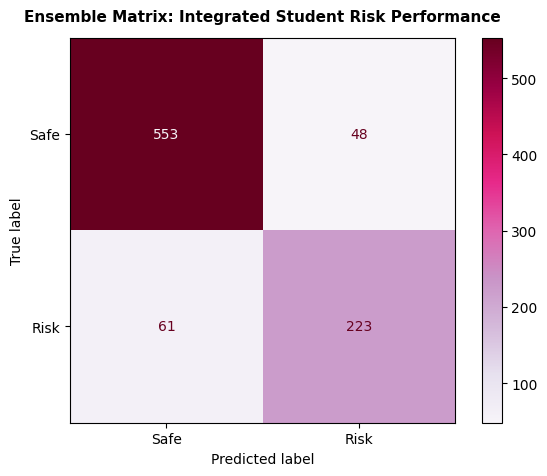

In [46]:
# Compile Random Forest, XGBoost, Light GBM, and SVC
named_estimators = [
    ('random_forest', rf_binary),
    ('xgb', xgb_binary),
    ('lightgbm', lgb_binary),
    ('svc', svc_binary)
]

# Initialize the Voting Classifier with 'soft' probabilities
ensemble_voting = VotingClassifier(
    estimators=named_estimators,
    voting='soft', 
    n_jobs=-1
)

ensemble_voting.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_ensemble_bin = ensemble_voting.predict(X_test_bin_scaled)

print("\nENSEMBLE VOTING PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_ensemble_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_ens = confusion_matrix(y_test_bin_int, y_pred_ensemble_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['Safe', 'Risk'])
disp_ens.plot(cmap='PuRd', ax=ax, values_format='d')
plt.title('Ensemble Matrix: Integrated Student Risk Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()

In [47]:
# --- RANDOM FOREST TUNING ---
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3,4,5,6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5,10,20],
    'max_features': [0.2, 0.4, 0.6, 'sqrt']
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42
)

# --- XGBOOST TUNING ---
xgb_param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 0.9]
}
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42
)

# --- LIGHTGBM TUNING ---
lgb_param_grid = {
    # 1. Limit Tree Complexity (Crucial for leaf-wise growth)
    'max_depth': [3, 4, 5, 6],
    'num_leaves': [7, 15, 31, 50], # Keep these well below 2^max_depth
    
    # 2. Prevent Niche Splits (Forces minimum samples per leaf node)
    'min_child_samples': [20, 30, 50, 100], 
    
    # 3. Add Hard Math Penalties (L1 and L2 Regularization)
    'reg_alpha': stats.uniform(0, 5),     # L1 regularization (lambda_l1)
    'reg_lambda': stats.uniform(0, 5),    # L2 regularization (lambda_l2)
    
    # 4. Feature and Row Subsampling (Adds randomness, breaks memorization)
    'subsample': [0.7, 0.8, 0.9],         # Fraction of rows per tree
    'colsample_bytree': [0.7, 0.8, 0.9],  # Fraction of columns/features per tree
    
    # 5. Slow Down the Learning Speed
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}
lgb_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42
)

# --- SVC TUNING ---
svc_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'kernel': ['rbf', 'linear']
}
svc_search = RandomizedSearchCV(
    estimator=SVC(random_state=42, probability=True), # Required for soft voting
    param_distributions=svc_param_grid,
    n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42
)

print("Running RandomizedSearchCV across the 4 base estimators...")
rf_search.fit(X_train_bin_scaled, y_train_bin_int)
xgb_search.fit(X_train_bin_scaled, y_train_bin_int)
lgb_search.fit(X_train_bin_scaled, y_train_bin_int)
svc_search.fit(X_train_bin_scaled, y_train_bin_int)

print("\nOPTIMIZED HYPERPARAMETER REPORT:")
print("=" * 50)
for name, search in [("Random Forest", rf_search), ("XGBoost", xgb_search), 
                     ("LightGBM", lgb_search), ("SVC", svc_search)]:
    print(f"Best {name} Params:")
    for param, value in search.best_params_.items():
        print(f"   • {param}: {value}")
    print("-" * 50)

Running RandomizedSearchCV across the 4 base estimators...

OPTIMIZED HYPERPARAMETER REPORT:
Best Random Forest Params:
   • n_estimators: 300
   • min_samples_split: 5
   • min_samples_leaf: 10
   • max_features: 0.6
   • max_depth: 6
--------------------------------------------------
Best XGBoost Params:
   • subsample: 0.7
   • n_estimators: 150
   • max_depth: 3
   • learning_rate: 0.05
   • colsample_bytree: 0.6
--------------------------------------------------
Best LightGBM Params:
   • colsample_bytree: 0.8
   • learning_rate: 0.03
   • max_depth: 5
   • min_child_samples: 30
   • n_estimators: 300
   • num_leaves: 50
   • reg_alpha: 2.571172192068058
   • reg_lambda: 2.9620728443102124
   • subsample: 0.9
--------------------------------------------------
Best SVC Params:
   • kernel: linear
   • gamma: 0.01
   • C: 1
--------------------------------------------------



BINARY MODEL PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.90      0.91      0.90       601
    Risk (Dropout)       0.80      0.78      0.79       284

          accuracy                           0.87       885
         macro avg       0.85      0.84      0.85       885
      weighted avg       0.87      0.87      0.87       885



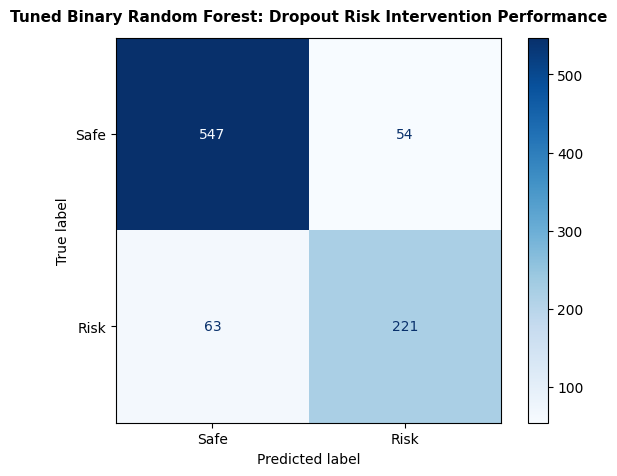

In [48]:
# Initialize the Random Forest Classifier
best_rf = RandomForestClassifier(n_estimators=300, min_samples_split=5, min_samples_leaf= 10, max_features=0.6, max_depth= 6, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_bin = best_rf.predict(X_test_bin_scaled)

print("\nBINARY MODEL PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_bin, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_bin = confusion_matrix(y_test_bin_int, y_pred_bin)
fig, ax = plt.subplots(figsize=(7, 5))
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['Safe', 'Risk'])
disp_bin.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Tuned Binary Random Forest: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


XGBOOST BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.88      0.90       601
    Risk (Dropout)       0.77      0.82      0.79       284

          accuracy                           0.86       885
         macro avg       0.84      0.85      0.85       885
      weighted avg       0.87      0.86      0.86       885



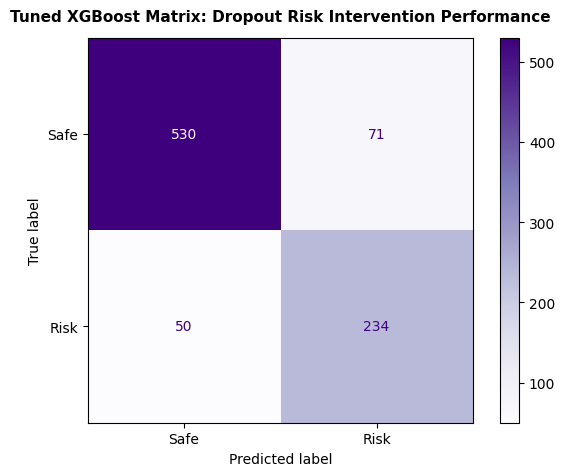

In [49]:
# Initialize the XGBoost Classifier
best_xgb = XGBClassifier(
    n_estimators=150,          
    learning_rate=0.05,         
    max_depth=3,                
    subsample=0.7,             
    colsample_bytree=0.6,      
    objective='binary:logistic',
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_xgb_bin_tuned = best_xgb.predict(X_test_bin_scaled)

print("\nXGBOOST BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_xgb_bin_tuned, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_xgb = confusion_matrix(y_test_bin_int, y_pred_xgb_bin_tuned)
fig, ax = plt.subplots(figsize=(7, 5))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Safe', 'Risk'])
disp_xgb.plot(cmap='Purples', ax=ax, values_format='d') 
plt.title('Tuned XGBoost Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


LIGHTGBM BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.92      0.89      0.90       601
    Risk (Dropout)       0.78      0.83      0.80       284

          accuracy                           0.87       885
         macro avg       0.85      0.86      0.85       885
      weighted avg       0.87      0.87      0.87       885



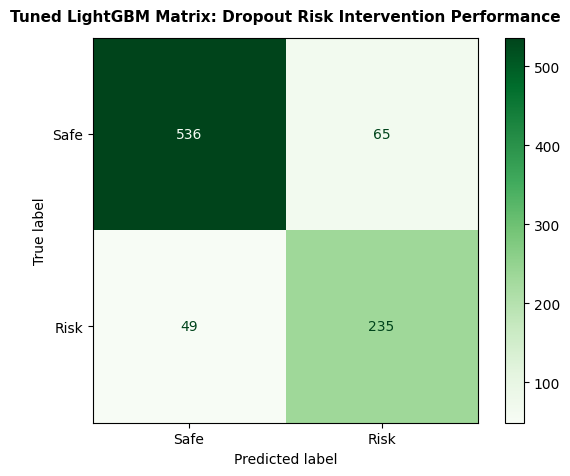

In [50]:
# Initialize the LightGBM Classifier
best_lgb = LGBMClassifier(
    subsample=0.9,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=50,             
    reg_alpha=2.571172192068058,
    reg_lambda=2.9620728443102124,
    is_unbalance=True,        
    random_state=42,
    n_jobs=-1,
    verbose=-1                 
)

best_lgb.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_lgb_bin_tuned = best_lgb.predict(X_test_bin_scaled)

print("\nLIGHTGBM BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_lgb_bin_tuned, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_lgb = confusion_matrix(y_test_bin_int, y_pred_lgb_bin_tuned)
fig, ax = plt.subplots(figsize=(7, 5))
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=['Safe', 'Risk'])
disp_lgb.plot(cmap='Greens', ax=ax, values_format='d') 
plt.title('Tuned LightGBM Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


SVC BINARY PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.89      0.90       601
    Risk (Dropout)       0.78      0.81      0.80       284

          accuracy                           0.87       885
         macro avg       0.84      0.85      0.85       885
      weighted avg       0.87      0.87      0.87       885



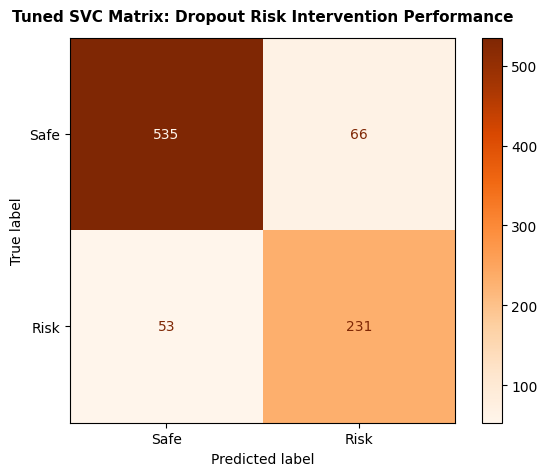

In [51]:
# Initialize the SVC
best_svc = SVC(
    kernel='linear',
    C=1.0,                       
    gamma=0.01,             
    class_weight='balanced',     
    probability=True,           
    random_state=42
)

best_svc.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_svc_bin_tuned = best_svc.predict(X_test_bin_scaled)

print("\nSVC BINARY PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_svc_bin_tuned, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

# Plot the confusion matrix
cm_svc = confusion_matrix(y_test_bin_int, y_pred_svc_bin_tuned)
fig, ax = plt.subplots(figsize=(7, 5))
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=['Safe', 'Risk'])
disp_svc.plot(cmap='Oranges', ax=ax, values_format='d') 
plt.title('Tuned SVC Matrix: Dropout Risk Intervention Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()


TUNED ENSEMBLE PERFORMANCE REPORT:

                    precision    recall  f1-score   support

Safe (Non-Dropout)       0.91      0.91      0.91       601
    Risk (Dropout)       0.81      0.81      0.81       284

          accuracy                           0.88       885
         macro avg       0.86      0.86      0.86       885
      weighted avg       0.88      0.88      0.88       885



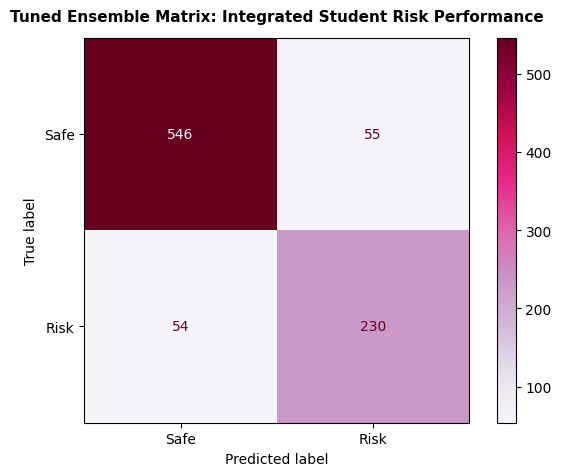

In [52]:
# Compile Random Forest, XGBoost, Light GBM, and SVC and initialize the Voting Classifier with 'soft' probabilities
tuned_ensemble = VotingClassifier(
    estimators=[
        ('random_forest', best_rf), 
        ('xgb', best_xgb),           
        ('lightgbm', best_lgb),       
        ('svc', best_svc)            
    ],
    voting='soft',
    n_jobs=-1
)

tuned_ensemble.fit(X_train_bin_scaled, y_train_bin_int)

# Predict and evaluate
y_pred_tuned = tuned_ensemble.predict(X_test_bin_scaled)

print("\nTUNED ENSEMBLE PERFORMANCE REPORT:\n")
print(classification_report(y_test_bin_int, y_pred_tuned, target_names=['Safe (Non-Dropout)', 'Risk (Dropout)']))

#  Plot the confusion matrix
cm_ens = confusion_matrix(y_test_bin_int, y_pred_tuned)
fig, ax = plt.subplots(figsize=(7, 5))
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['Safe', 'Risk'])
disp_ens.plot(cmap='PuRd', ax=ax, values_format='d') # Gold for the ultimate champion model
plt.title('Tuned Ensemble Matrix: Integrated Student Risk Performance', fontsize=11, fontweight='bold', pad=12)
plt.show()

In [53]:
# Get predictions for both sets
y_train_pred = tuned_ensemble.predict(X_train_bin_scaled)
y_test_pred = tuned_ensemble.predict(X_test_bin_scaled)

# Calculate scores
train_f1 = f1_score(y_train_bin_int, y_train_pred)
test_f1 = f1_score(y_test_bin_int, y_test_pred)

print(f"Training Risk F1-Score: {train_f1:.4f}")
print(f"Testing Risk F1-Score:  {test_f1:.4f}")
print(f"The Generalization Gap:  {train_f1 - test_f1:.4f}")

Training Risk F1-Score: 0.8252
Testing Risk F1-Score:  0.8084
The Generalization Gap:  0.0168


In [54]:
# Create a container to store the results
model_performance = []

# Loop through each base estimator in your ensemble
for i, model in enumerate(tuned_ensemble.estimators_):
    # Get the model's class name
    model_name = model.__class__.__name__
    
    # Predict on training and testing sets using the specific sub-model
    y_train_pred_sub = model.predict(X_train_bin_scaled)
    y_test_pred_sub = model.predict(X_test_bin_scaled)
    
    # Calculate scores
    sub_train_f1 = f1_score(y_train_bin_int, y_train_pred_sub)
    sub_test_f1 = f1_score(y_test_bin_int, y_test_pred_sub)
    gap = sub_train_f1 - sub_test_f1
    
    # Store the metrics
    model_performance.append({
        "Model Index": i,
        "Model Name": model_name,
        "Train F1": sub_train_f1,
        "Test F1": sub_test_f1,
        "Gap": gap
    })

# Convert to a DataFrame and sort by the largest gap
perf_df = pd.DataFrame(model_performance).sort_values(by="Gap", ascending=False)
print("Individual Base Model Performance:")
print(perf_df.to_string(index=False))

Individual Base Model Performance:
 Model Index             Model Name  Train F1  Test F1       Gap
           2         LGBMClassifier  0.852332 0.804795  0.047537
           0 RandomForestClassifier  0.811270 0.790698  0.020572
           1          XGBClassifier  0.809790 0.794567  0.015223
           3                    SVC  0.794437 0.795181 -0.000744


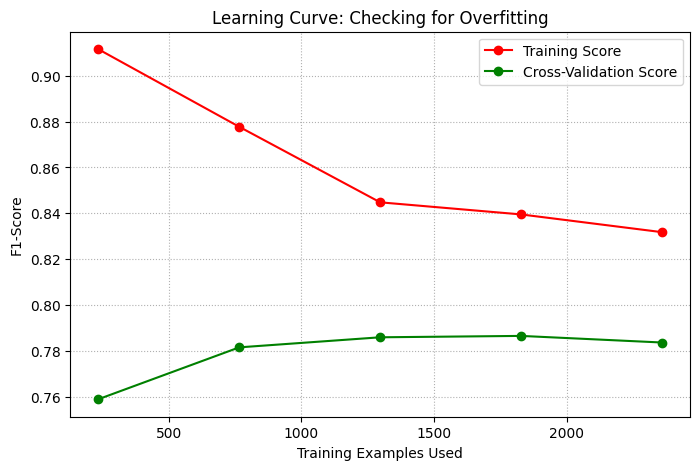

In [55]:
# Compute learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=tuned_ensemble,
    X=X_train_bin_scaled,
    y=y_train_bin_int,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Calculate means
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot the curves
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")
plt.title("Learning Curve: Checking for Overfitting")
plt.xlabel("Training Examples Used")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True, linestyle=':')
plt.show()

In [ ]:
target_feature = 'Admission_grade' 
fig, ax = plt.subplots(figsize=(9, 6))

# Build the combined PDP and ICE display
display = PartialDependenceDisplay.from_estimator(
    estimator=tuned_ensemble,
    X=X_train_bin_scaled,                 
    features=[target_feature],            
    kind='both',                          
    pd_line_kw={"color": "red", "linewidth": 4},
    ice_lines_kw={"color": "teal", "alpha": 0.05, "linewidth": 0.5}, 
    ax=ax,
    n_jobs=-1
)

plt.title(f'PDP & ICE Curves: How {target_feature} Drives Dropout Risk', fontsize=12, fontweight='bold', pad=15)
plt.xlabel(f'Scaled Feature Value: {target_feature}', fontsize=10)
plt.ylabel('Partial Dependence (Log-Odds of Dropout Risk)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

pdp_handle = mlines.Line2D([], [], color='red', linewidth=3, label='Global Average Trend (PDP)')
ice_handle = mlines.Line2D([], [], color='teal', alpha=0.6, linewidth=1.5, label='Individual Student Paths (ICE)')
ax.legend(handles=[pdp_handle, ice_handle], loc='best')

plt.tight_layout()
plt.show()

In [ ]:
target_feature = 'Curricular_units_2nd_sem_approved' 
fig, ax = plt.subplots(figsize=(9, 6))

# Build the combined PDP and ICE display
display = PartialDependenceDisplay.from_estimator(
    estimator=tuned_ensemble,
    X=X_train_bin_scaled,                 
    features=[target_feature],            
    kind='both',                          
    pd_line_kw={"color": "red", "linewidth": 4},
    ice_lines_kw={"color": "teal", "alpha": 0.05, "linewidth": 0.5}, 
    ax=ax,
    n_jobs=-1
)

plt.title(f'PDP & ICE Curves: How {target_feature} Drives Dropout Risk', fontsize=12, fontweight='bold', pad=15)
plt.xlabel(f'Scaled Feature Value: {target_feature}', fontsize=10)
plt.ylabel('Partial Dependence (Log-Odds of Dropout Risk)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

pdp_handle = mlines.Line2D([], [], color='red', linewidth=3, label='Global Average Trend (PDP)')
ice_handle = mlines.Line2D([], [], color='teal', alpha=0.6, linewidth=1.5, label='Individual Student Paths (ICE)')
ax.legend(handles=[pdp_handle, ice_handle], loc='best')

plt.tight_layout()
plt.show()

In [ ]:
# Map the binary 0 and 1 to clean text strings
sensitive_feature_gender = X_test['Gender'].map({0: 'Female', 1: 'Male'})
# Generate predictions from tuned ensemble
y_pred = tuned_ensemble.predict(X_test_bin_scaled)

# Create a MetricFrame to slice performance across groups
metrics = {
    'Accuracy': accuracy_score,
    'F1-Score': f1_score,
    'Selection Rate (Rate of flagging Risk)': selection_rate
}

metric_frame_gender = MetricFrame(
    metrics=metrics,
    y_true=y_test_bin_int,               
    y_pred=y_pred,                       
    sensitive_features=sensitive_feature_gender  # <-- Pass the mapped text version here
)

print("PER-GROUP PERFORMANCE AUDIT:")
print(metric_frame_gender.by_group)

In [ ]:
# Demographic Parity Difference
# Ideal: 0.0 (Every group is flagged as "Risk" at the exact same rate)
dp_diff = demographic_parity_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_gender
)

# Equalized Odds Difference
# Ideal: 0.0 (The True Positive Rate and False Positive Rate are equal across all groups)
eo_diff = equalized_odds_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_gender
)

# Disparate Impact Ratio
# Ideal: 80% to 125% (The ratio of selection rates between the lowest group and highest group)
group_selection_rates = metric_frame_gender.by_group['Selection Rate (Rate of flagging Risk)']
disparate_impact = group_selection_rates.min() / group_selection_rates.max()

print("\nGLOBAL FAIRNESS AUDIT METRICS:")
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference:     {eo_diff:.4f}")
print(f"Disparate Impact Ratio:         {disparate_impact:.4f}")

In [ ]:
# Define a mapping function for age group
def assign_age_group(age):
    if age <= 21:
        return 'Traditional (<=21)'
    elif age <= 30:
        return 'Young Adult (22-30)'
    else:
        return 'Mature-Age (>30)'

# Apply the function to make a new column for train and test sets
X_train['Age_Group'] = X_train['Age'].apply(assign_age_group)
X_test['Age_Group'] = X_test['Age'].apply(assign_age_group)

print("Train Set Age Group Distribution:")
print(X_train['Age_Group'].value_counts())

In [ ]:
sensitive_feature_age = X_test['Age_Group']
metric_frame_age = MetricFrame(
    metrics=metrics,
    y_true=y_test_bin_int,               
    y_pred=y_pred,                       
    sensitive_features=sensitive_feature_age
)
print("PER-GROUP PERFORMANCE AUDIT:")
print(metric_frame_age.by_group)

In [ ]:
# Demographic Parity Difference
# Ideal: 0.0 (Every group is flagged as "Risk" at the exact same rate)
dp_diff = demographic_parity_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_age
)

# Equalized Odds Difference
# Ideal: 0.0 (The True Positive Rate and False Positive Rate are equal across all groups)
eo_diff = equalized_odds_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_age
)

# Disparate Impact Ratio
# Ideal: 80% to 125% (The ratio of selection rates between the lowest group and highest group)
group_selection_rates = metric_frame_age.by_group['Selection Rate (Rate of flagging Risk)']
disparate_impact = group_selection_rates.min() / group_selection_rates.max()

print("\nGLOBAL FAIRNESS AUDIT METRICS:")
print(f"🔹 Demographic Parity Difference: {dp_diff:.4f}")
print(f"🔹 Equalized Odds Difference:     {eo_diff:.4f}")
print(f"🔹 Disparate Impact Ratio:         {disparate_impact:.4f}")

In [ ]:
sensitive_feature_debt = X_test['Debtor']
metric_frame_debt = MetricFrame(
    metrics=metrics,
    y_true=y_test_bin_int,               
    y_pred=y_pred,                       
    sensitive_features=sensitive_feature_debt
)
print("PER-GROUP PERFORMANCE AUDIT:")
print(metric_frame_debt.by_group)

In [ ]:
# Demographic Parity Difference
# Ideal: 0.0 (Every group is flagged as "Risk" at the exact same rate)
dp_diff = demographic_parity_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_debt
)

# Equalized Odds Difference
# Ideal: 0.0 (The True Positive Rate and False Positive Rate are equal across all groups)
eo_diff = equalized_odds_difference(
    y_test_bin_int, y_pred, sensitive_features=sensitive_feature_debt
)

# Disparate Impact Ratio
# Ideal: 80% to 125% (The ratio of selection rates between the lowest group and highest group)
group_selection_rates = metric_frame_debt.by_group['Selection Rate (Rate of flagging Risk)']
disparate_impact = group_selection_rates.min() / group_selection_rates.max()

print("\nGLOBAL FAIRNESS AUDIT METRICS:")
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"qualized Odds Difference:     {eo_diff:.4f}")
print(f"Disparate Impact Ratio:         {disparate_impact:.4f}")